# Fairness-Aware Health Insurance Churn Prediction
## Orthogonalization + Reweighting

보험 해지(이탈) 예측 모델의 **그룹 공정성**을 개선하기 위한 분석 노트북입니다.
민감변수(나이·성별, 거주지/소득 대리변수)에 따른 **거짓양성률 격차(FPR Gap)**를
두 가지 전처리 기법으로 완화합니다.

- **Orthogonalization (직교화):** 각 피처에서 민감변수 기저(age 더미·gender·교호작용·age 연속형·age²)로
  설명되는 성분을 Ridge 회귀 잔차로 제거하여 *간접차별* 경로를 차단합니다.
- **Reweighting (재가중):** `age_group × gender` 교차 그룹의 역빈도 가중치를 학습에 적용해
  집단 간 학습 불균형을 보정합니다.

두 기법을 **XGBoost**와 **GLM(로지스틱 회귀)** 두 모델에 각각 적용하고,
PR-AUC 하락 2% 이내 제약 하에서 FPR Gap이 최소가 되는 직교화 임계값을 Pareto 탐색으로 선택합니다.

### 실행 방법
1. 아래 **`3. 파일 경로 설정`** 셀의 `BASE_PATH` 한 곳만 본인 환경에 맞게 수정하세요.
   (모델·데이터·GLM 경로가 모두 `BASE_PATH`에서 파생됩니다.)
2. 필요한 입력 파일: 모델 패키지 pkl, 데이터 pkl (개인정보 보호를 위해 원본 데이터는 포함하지 않습니다).
3. 위에서부터 순서대로 실행합니다. (Google Colab + GPU 환경 기준으로 작성됨)

### 주요 출력
- 민감변수별 FPR 분포 및 FPR Gap 비교 그래프
- Base / Orth / RW / Orth+RW 성능·공정성 비교표
- 변수별 가중 평가 기반 최종 방법론 선정 결과
- 변수별 공정성 리포트(JSON)


## 0. 패키지 설치

In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib -q
print("설치 완료")


설치 완료


In [2]:
# ── 코랩 한글 폰트 설정 ─────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔고딕 설치
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
subprocess.run(['fc-cache', '-fv'], capture_output=True)

# 폰트 캐시 재빌드
fm._load_fontmanager(try_read_cache=False)

# 나눔고딕 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
matplotlib.rcParams['font.family'] = font_prop.get_name()
matplotlib.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

print(f"한글 폰트 설정 완료: {font_prop.get_name()}")

한글 폰트 설정 완료: NanumGothic


## 1. Google Drive 마운트

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. 라이브러리 임포트

In [4]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, average_precision_score
)

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
print("임포트 완료")

임포트 완료


## 3. 파일 경로 설정


In [5]:
BASE_PATH  = '/content/drive/MyDrive/Colab Notebooks/리스크 공모전'

MODEL_PKL  = f'{BASE_PATH}/xgb_package2.pkl'   # 모델 패키지 pkl
DATA_PKL   = f'{BASE_PATH}/Health_Insurance_final.pkl'      # 데이터 pkl

TARGET_COL = 'is_churn'
AGE_COL    = 'age'

AGE_BINS   = [0, 20, 30, 40, 50, 60, 70, 100]
AGE_LABELS = ['10s', '20s', '30s','40s', '50s', '60s', '70s+']

print("경로 설정 완료")
print(f"  모델 pkl : {MODEL_PKL}")
print(f"  데이터 pkl: {DATA_PKL}")

경로 설정 완료
  모델 pkl : /content/drive/MyDrive/Colab Notebooks/리스크 공모전/xgb_package2.pkl
  데이터 pkl: /content/drive/MyDrive/Colab Notebooks/리스크 공모전/Health_Insurance_final.pkl


## 4. 모델 패키지 로드 (`xgb_package2.pkl`)

In [6]:
with open(MODEL_PKL, 'rb') as f:
    pkg = pickle.load(f)

base_model     = pkg['model']
feature_names  = pkg['feature_names']
threshold = float(pkg['threshold'])
fixed_params   = {k: v for k, v in pkg['fixed_params'].items()
                  if k not in ('device', 'early_stopping_rounds')}
best_params    = pkg['best_params']

print("=== 모델 패키지 로드 완료 ===")
print(f"feature_names ({len(feature_names)}개): {feature_names}")
print(f"base_threshold: {threshold:.4f}")
print(f"fixed_params  : {fixed_params}")
print(f"best_params   : {best_params}")


=== 모델 패키지 로드 완료 ===
feature_names (22개): ['premium', 'seniority_policy', 'type_policy_dg', 'type_product', 'new_business', 'log_cost_claims_year', 'distribution_channel', 'age', 'gender', 'IICIMUN_capped', 'IICIPROV', 'C_C', 'C_H_num', 'C_GI', 'C_IE_T', 'missing_geo_cxt', 'high_loss', 'relative_poverty', 'kr_premium_shock', 'kr_economic_stress', 'kr_early_laps', 'kr_medical_desert']
base_threshold: 0.5024
fixed_params  : {'n_estimators': 276, 'scale_pos_weight': np.float64(4.257625348189415), 'tree_method': 'hist', 'random_state': 1746, 'eval_metric': 'aucpr'}
best_params   : {'max_depth': 9, 'learning_rate': 0.031598834246705135, 'min_child_weight': 1, 'subsample': 0.6637275922531015, 'colsample_bytree': 0.6433347033971591, 'gamma': 1.4617584706638308e-07, 'reg_alpha': 0.11592854366922457, 'reg_lambda': 0.003985653950301569}


## 5. 데이터 로드 및 전처리

In [7]:
with open(DATA_PKL, 'rb') as f:
    data = pickle.load(f)

print(f"데이터 shape: {data.shape}")
print(data.head(5))
print("\ndtypes:")
print(data.dtypes)

데이터 shape: (226666, 43)
   lapse  exposure_time  premium  seniority_insured  seniority_policy  \
0      1       0.969749  2923.32                 24                24   
1      2       1.000000  1930.11                 24                24   
2      2       1.000000  2020.00                 24                24   
3      2       1.000000  1843.25                 24                24   
4      2       1.000000  1316.03                 24                24   

  type_policy_dg type_product new_business  cost_claims_year  \
0              I            S           No           8242.62   
1              I            S           No            344.41   
2              I            P           No            523.18   
3              I            S           No            257.55   
4              I            S           No            420.16   

   n_medical_services  ... IICIMUN_capped help_requested  high_loss  \
0                  32  ...      22.842273              1   2.819609   
1         

In [8]:
target = 'is_churn'

x_cols = [
    # 기본
    'premium', 'seniority_policy', 'type_policy_dg', 'type_product', 'new_business',
    'log_cost_claims_year', 'distribution_channel',
    # 나이 관련
    'age',
    # 성별 관련
    'gender',
    # 지역 관련
    'IICIMUN_capped', 'IICIPROV', 'C_C', 'C_H_num', 'C_GI', 'C_IE_T',
]

der_cols = [
    'missing_geo_cxt',       # 지역 결측 신호
    'high_loss',                  # 보험사 손해율
    'relative_poverty',        # 지역 내 상대적 빈곤
    'kr_premium_shock',   # 가격 인상 압박(비율 단위)
    'kr_economic_stress',  # 소득 대비 체감 부담
    # 'kr_retention_years',    # 장기 유지 혜택
    'kr_early_laps',             #신계약 위험 구간
    # 'kr_direct_channel',     # 가입 채널 영향
    'kr_medical_desert'     # 인프라 취약성
]

### Encoding
cat_cols = ['type_policy_dg', 'type_product', 'new_business', 'distribution_channel', 'gender', 'C_C', 'kr_early_laps']

In [9]:
### train/test split
for col in cat_cols:
    data[col] = data[col].astype(str).astype('category')

train = data[data['period'].isin([2017, 2018])]
test = data[data['period'] == 2019]

x_train = train[x_cols]
y_train = train[target]
x_test = test[x_cols]
y_test = test[target]

In [10]:
# base 모델 성능지표 확인
import pandas as pd
import numpy as np

# base 모델 성능지표 확인
x_test_prepared = test[feature_names].copy()

# category dtype 유지 (float 변환 하지 않음)
for col in cat_cols:
    if col in x_test_prepared.columns:
        x_test_prepared[col] = x_test_prepared[col].astype(str).astype('category')

prob_base = base_model.predict_proba(x_test_prepared)[:, 1]
pred_base = (prob_base >= threshold).astype(int)

from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, pred_base, labels=[0,1]).ravel()
print("=== Base Model (pkl 로드) ===")
print(f"  PR-AUC   : {average_precision_score(y_test, prob_base):.4f}")
print(f"  F1       : {f1_score(y_test, pred_base, zero_division=0):.4f}")
print(f"  Precision: {precision_score(y_test, pred_base, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_test, pred_base, zero_division=0):.4f}")
print(f"  FPR      : {fp/(fp+tn):.4f}")
print(f"  threshold: {threshold:.4f}")


=== Base Model (pkl 로드) ===
  PR-AUC   : 0.3990
  F1       : 0.4128
  Precision: 0.3381
  Recall   : 0.5301
  FPR      : 0.1994
  threshold: 0.5024


## 6. 직교화 기저 행렬 (age 연속형 + 비선형 포함)

In [11]:
from sklearn.preprocessing import OneHotEncoder

train_ag = pd.cut(train[AGE_COL], bins=AGE_BINS, labels=AGE_LABELS)
test_ag  = pd.cut(test[AGE_COL],  bins=AGE_BINS, labels=AGE_LABELS)

# age_group 더미
enc = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
age_dum_tr = enc.fit_transform(train_ag.values.reshape(-1, 1))
age_dum_te = enc.transform(test_ag.values.reshape(-1, 1))

# gender 더미
gender_ref = train['gender'].astype(str).unique()[1]
gender_tr = (train['gender'].astype(str) == gender_ref).astype(float).values.reshape(-1, 1)
gender_te = (test['gender'].astype(str)  == gender_ref).astype(float).values.reshape(-1, 1)

# 교호작용
interact_tr = age_dum_tr * gender_tr
interact_te = age_dum_te * gender_te

# age 연속형 + age² (비선형 패턴 포착)
age_c_tr = train['age'].values.astype(float).reshape(-1, 1)
age_c_te = test['age'].values.astype(float).reshape(-1, 1)
age_mu, age_sd = age_c_tr.mean(), age_c_tr.std()
age_n_tr = (age_c_tr - age_mu) / age_sd
age_n_te = (age_c_te - age_mu) / age_sd

basis_tr = np.hstack([age_dum_tr, gender_tr, interact_tr, age_n_tr, age_n_tr**2])
basis_te = np.hstack([age_dum_te, gender_te, interact_te, age_n_te, age_n_te**2])

print(f"기저 행렬: train={basis_tr.shape} (더미{age_dum_tr.shape[1]} + gender1 + interact{interact_tr.shape[1]} + age_cont + age²)")


기저 행렬: train=(150999, 15) (더미6 + gender1 + interact6 + age_cont + age²)


## 7. Feature별 R² 측정

In [12]:
from sklearn.linear_model import LinearRegression

cat_cols = ['type_policy_dg','type_product','new_business','distribution_channel','gender','C_C','kr_early_laps']

x_train_num = train[feature_names].copy()
x_test_num  = test[feature_names].copy()
for col in cat_cols:
    if col in x_train_num.columns:
        x_train_num[col] = x_train_num[col].astype(str).astype('category').cat.codes.astype(float)
        x_test_num[col]  = x_test_num[col].astype(str).astype('category').cat.codes.astype(float)

r2_dict = {}
for col in feature_names:
    if col in ('age', 'gender'): continue
    x_tr = x_train_num[col].values.astype(float)
    if np.isnan(x_tr).any() or np.std(x_tr) == 0: r2_dict[col] = 0.0; continue
    pred = LinearRegression().fit(basis_tr, x_tr).predict(basis_tr)
    ss_res = np.sum((x_tr - pred)**2)
    ss_tot = np.sum((x_tr - x_tr.mean())**2)
    r2_dict[col] = round(max(0.0, 1 - ss_res/ss_tot), 4)

r2_series = pd.Series(r2_dict).sort_values(ascending=False)
print("Feature별 R² (age+gender+교호+age연속+age² 기저):")
print(r2_series.to_string())


Feature별 R² (age+gender+교호+age연속+age² 기저):
kr_premium_shock        0.9276
seniority_policy        0.2406
premium                 0.2004
kr_early_laps           0.1336
log_cost_claims_year    0.0605
distribution_channel    0.0494
new_business            0.0456
C_IE_T                  0.0246
C_H_num                 0.0245
C_GI                    0.0132
high_loss               0.0106
IICIMUN_capped          0.0101
C_C                     0.0090
type_policy_dg          0.0082
relative_poverty        0.0082
missing_geo_cxt         0.0058
kr_medical_desert       0.0051
type_product            0.0045
kr_economic_stress      0.0026
IICIPROV                0.0019


## 8. 민감변수 그룹 정의

In [13]:
# 8. 민감변수 그룹 정의
AG_BINS, AG_LABELS = [0, 25, 40, 60, 200], ['청년','중년','장년','고령']
test_age_gender = (
    pd.cut(test['age'], bins=AG_BINS, labels=AG_LABELS).astype(str)
    + '_' + test['gender'].astype(str)
)
train_age_gender = (
    pd.cut(train['age'], bins=AG_BINS, labels=AG_LABELS).astype(str)
    + '_' + train['gender'].astype(str)
)

# ── 민감변수 구간/매핑 설정 ──────────────────────────────────────────
# C_GI, C_IE_T : 0~100 사이 수치 → 의미 있는 4구간 + Unknown
# C_H_num      : 금액 코드 → H1~H6 레이블 매핑
sens_config = {
    'c_gi': {
        'col': 'C_GI',
        'bins':   [-2, 0, 25, 50, 75, 100],
        'labels': ['Unknown', 'GI_1', 'GI_2', 'GI_3', 'GI_4'],
    },
    'c_ie_t': {
        'col': 'C_IE_T',
        'bins':   [-2, 0, 25, 50, 75, 100],
        'labels': ['Unknown', 'C_IE_T_1', 'C_IE_T_2', 'C_IE_T_3', 'C_IE_T_4'],
    },
    'c_h': {
        'col': 'C_H_num',
        'map': {500: 'H1', 5500: 'H2', 17500: 'H3',
                37500: 'H4', 75000: 'H5', 150000: 'H6', -1: 'Unknown'},
    },
}

# 그룹 컬럼 생성 (train/test 공통)
for key, cfg in sens_config.items():
    col = cfg['col']
    for df in [train, test]:
        if 'bins' in cfg:
            df[f'{col}_grp'] = pd.cut(
                df[col], bins=cfg['bins'], labels=cfg['labels'],
                right=True, include_lowest=True
            ).astype(str)
        else:
            df[f'{col}_grp'] = df[col].map(cfg['map']).fillna('Unknown')

sensitive_test = {
    'age_group':  test_ag,
    'gender':     test['gender'].astype(str),
    'age_gender': test_age_gender,
    'c_h':        test['C_H_num_grp'],
    'c_gi':       test['C_GI_grp'],
    'c_ie_t':     test['C_IE_T_grp'],
}

for k, v in sensitive_test.items():
    print(f"  {k:12s}: {sorted(v.unique())}")


  age_group   : ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
  gender      : ['F', 'M']
  age_gender  : ['고령_F', '고령_M', '장년_F', '장년_M', '중년_F', '중년_M', '청년_F', '청년_M']
  c_h         : ['H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'Unknown']
  c_gi        : ['GI_1', 'GI_2', 'GI_3', 'GI_4', 'Unknown']
  c_ie_t      : ['C_IE_T_1', 'C_IE_T_2', 'C_IE_T_3', 'C_IE_T_4', 'Unknown']


## 9. 공통 유틸

In [14]:
def calc_fpr(yt, yp):
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
    return fp/(fp+tn) if (fp+tn)>0 else 0.0

def group_fpr_dict(y_true, y_pred, groups):
    d = {}
    for g in sorted(groups.dropna().unique()):
        mask = (groups == g).values
        if mask.sum() < 10: continue
        yt, yp = np.array(y_true)[mask], np.array(y_pred)[mask]
        if len(np.unique(yt)) < 2: continue
        d[g] = round(calc_fpr(yt, yp), 4)
    return d

def fpr_gap(d):
    v = list(d.values())
    return round(max(v)-min(v), 4) if len(v)>=2 else 0.0

def avg_fpr_gap(y_true, y_pred, sd):
    return round(np.mean([fpr_gap(group_fpr_dict(y_true, y_pred, g)) for g in sd.values()]), 4)

def get_metrics(yt, yp, ypr):
    tn,fp,fn,tp = confusion_matrix(yt, ypr, labels=[0,1]).ravel()
    return {'PR-AUC': round(average_precision_score(yt,yp),4), 'F1': round(f1_score(yt,ypr,zero_division=0),4),
            'Precision': round(precision_score(yt,ypr,zero_division=0),4), 'Recall': round(recall_score(yt,ypr,zero_division=0),4),
            'FPR': round(fp/(fp+tn),4)}
print("유틸 정의 완료")


유틸 정의 완료


## 10. R² Threshold Pareto 탐색
- 기저 행렬: age_group 더미 + gender + 교호작용 + **age 연속형 + age²**
- PR-AUC 허용 하락: Base × **2%**
- Feasibility: 모든 민감변수 Avg FPR Gap 기준


In [15]:
from sklearn.linear_model import Ridge

R2_GRID = [0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3]
base_prauc = average_precision_score(y_test, prob_base)
PRAUC_DROP_LIMIT = base_prauc * 0.02   # 2%

print(f"Base PR-AUC: {base_prauc:.4f}, 허용 하락: {PRAUC_DROP_LIMIT:.4f} (2%)")

pareto_results = []
for r2_thr in R2_GRID:
    cols = r2_series[r2_series > r2_thr].index.tolist()
    x_tr_o, x_te_o = x_train_num.copy(), x_test_num.copy()
    for col in cols:
        reg = Ridge(alpha=1.0).fit(basis_tr, x_train_num[col].values.astype(float))
        x_tr_o[col] = x_train_num[col].values.astype(float) - reg.predict(basis_tr)
        x_te_o[col] = x_test_num[col].values.astype(float) - reg.predict(basis_te)

    # ★ scale_pos_weight 제거 (Pareto와 실제 학습 조건 일치)
    p = {**best_params, **fixed_params, 'tree_method':'hist', 'device':'cpu'}
    p.pop('early_stopping_rounds', None)
    p.pop('scale_pos_weight', None)

    m = XGBClassifier(**p, enable_categorical=False)
    m.fit(x_tr_o.to_numpy(dtype=float), y_train, verbose=False)
    prob_o = m.predict_proba(x_te_o.to_numpy(dtype=float))[:, 1]
    pred_o = (prob_o >= threshold).astype(int)

    prauc = average_precision_score(y_test, prob_o)
    gap = avg_fpr_gap(y_test, pred_o, sensitive_test)
    ok = (base_prauc - prauc) <= PRAUC_DROP_LIMIT

    pareto_results.append({'R2_thr':r2_thr, 'n_cols':len(cols), 'PR-AUC':round(prauc,4),
        'F1':round(f1_score(y_test,pred_o,zero_division=0),4), 'Avg FPR Gap':gap,
        'drop':round(base_prauc-prauc,4), 'ok':ok, 'prob':prob_o, 'pred':pred_o})
    print(f"  R²>{r2_thr:.2f} | {len(cols):2d}개 | PR-AUC={prauc:.4f}({base_prauc-prauc:+.4f}) | AvgGap={gap:.4f} {'✅' if ok else '❌'}")

pareto_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ('prob','pred')} for r in pareto_results]).set_index('R2_thr')
display(pareto_df)


Base PR-AUC: 0.3990, 허용 하락: 0.0080 (2%)
  R²>0.01 | 12개 | PR-AUC=0.3969(+0.0021) | AvgGap=0.0145 ✅
  R²>0.02 |  9개 | PR-AUC=0.3970(+0.0019) | AvgGap=0.0177 ✅
  R²>0.03 |  7개 | PR-AUC=0.3993(-0.0004) | AvgGap=0.0158 ✅
  R²>0.05 |  5개 | PR-AUC=0.3942(+0.0048) | AvgGap=0.0167 ✅
  R²>0.08 |  4개 | PR-AUC=0.3938(+0.0052) | AvgGap=0.0154 ✅
  R²>0.10 |  4개 | PR-AUC=0.3938(+0.0052) | AvgGap=0.0154 ✅
  R²>0.15 |  3개 | PR-AUC=0.3928(+0.0062) | AvgGap=0.0175 ✅
  R²>0.20 |  3개 | PR-AUC=0.3928(+0.0062) | AvgGap=0.0175 ✅
  R²>0.30 |  1개 | PR-AUC=0.3930(+0.0060) | AvgGap=0.0156 ✅


,n_cols,PR-AUC,F1,Avg FPR Gap,drop,ok
R2_thr,,,,,,
0.01,12,0.3969,0.1813,0.0145,0.0021,True
0.02,9,0.3970,0.1885,0.0177,0.0019,True
0.03,7,0.3993,0.1856,0.0158,-0.0004,True
0.05,5,0.3942,0.1873,0.0167,0.0048,True
0.08,4,0.3938,0.1762,0.0154,0.0052,True
0.10,4,0.3938,0.1762,0.0154,0.0052,True
0.15,3,0.3928,0.1724,0.0175,0.0062,True
0.20,3,0.3928,0.1724,0.0175,0.0062,True
0.30,1,0.3930,0.1937,0.0156,0.0060,True


최적: R²>0.01, 12개, PR-AUC=0.3969, AvgGap=0.0145


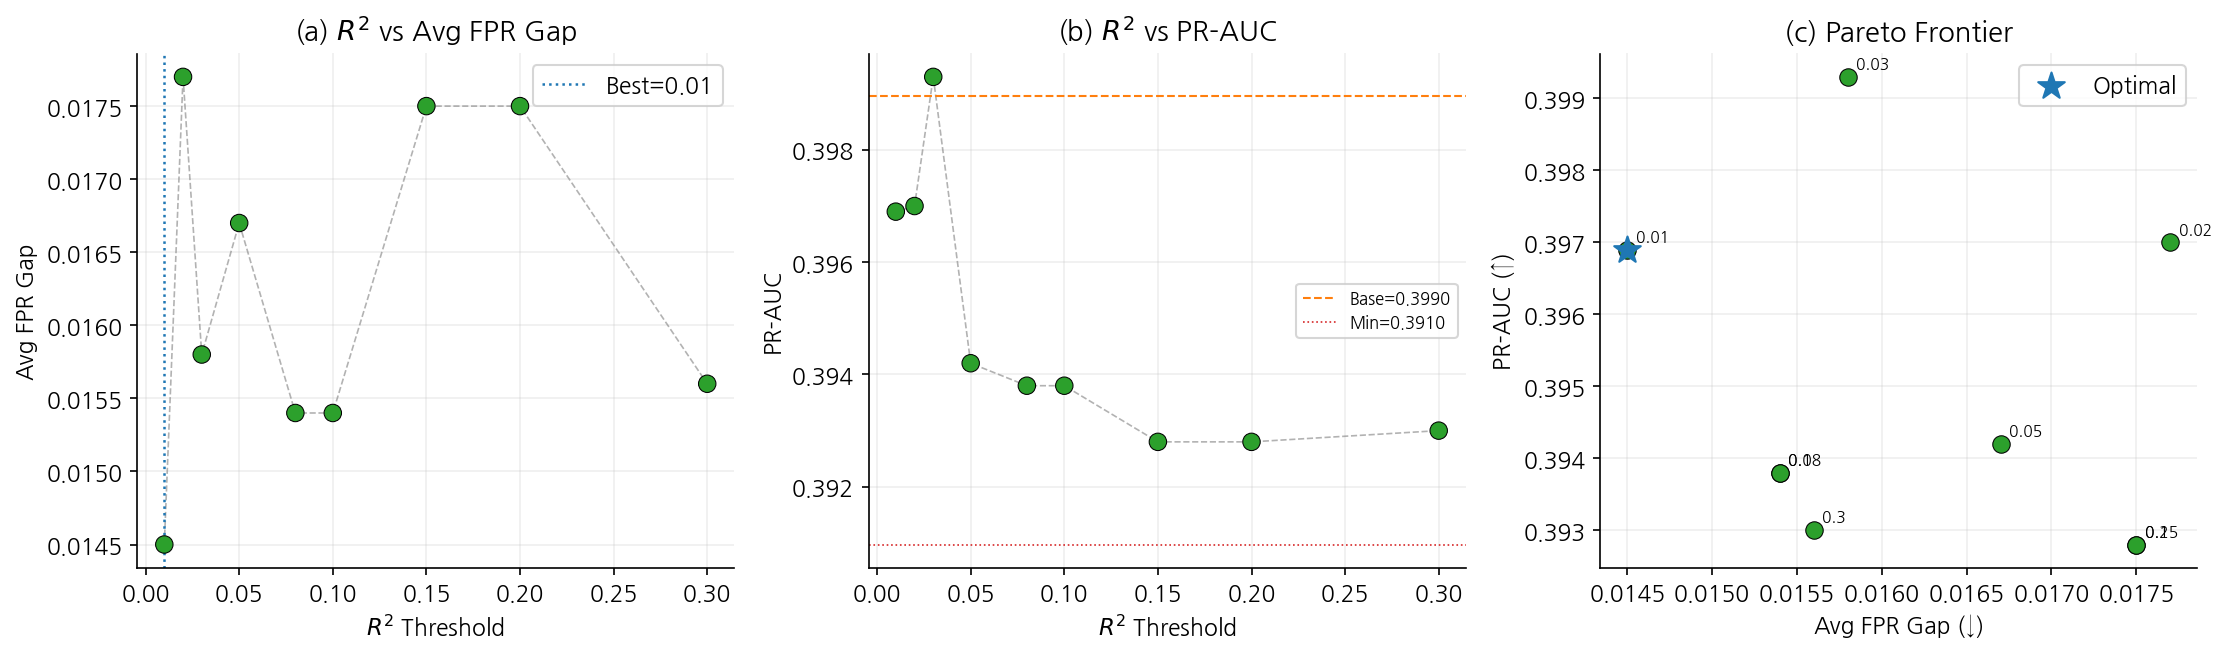

In [16]:
feas = [r for r in pareto_results if r['ok']]
best_r2 = min(feas, key=lambda r: r['Avg FPR Gap']) if feas else None
if best_r2:
    print(f"최적: R²>{best_r2['R2_thr']}, {best_r2['n_cols']}개, PR-AUC={best_r2['PR-AUC']:.4f}, AvgGap={best_r2['Avg FPR Gap']:.4f}")
    prob_orth, pred_orth = best_r2['prob'], best_r2['pred']
else: print("feasible 없음")

import matplotlib; matplotlib.rcParams.update({'font.size':11,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':150})
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
c = ['#2ca02c' if r else '#d62728' for r in pareto_df['ok']]

ax=axes[0]; ax.scatter(pareto_df.index, pareto_df['Avg FPR Gap'], c=c, s=70, zorder=5, edgecolors='k', linewidths=0.5)
ax.plot(pareto_df.index, pareto_df['Avg FPR Gap'], 'gray', lw=0.8, ls='--', alpha=0.6)
if best_r2: ax.axvline(best_r2['R2_thr'], color='#1f77b4', lw=1.2, ls=':', label=f"Best={best_r2['R2_thr']}")
ax.set_xlabel('$R^2$ Threshold'); ax.set_ylabel('Avg FPR Gap'); ax.set_title('(a) $R^2$ vs Avg FPR Gap'); ax.legend(); ax.grid(alpha=0.2)

ax=axes[1]; ax.scatter(pareto_df.index, pareto_df['PR-AUC'], c=c, s=70, zorder=5, edgecolors='k', linewidths=0.5)
ax.plot(pareto_df.index, pareto_df['PR-AUC'], 'gray', lw=0.8, ls='--', alpha=0.6)
ax.axhline(base_prauc, color='#ff7f0e', lw=1, ls='--', label=f'Base={base_prauc:.4f}')
ax.axhline(base_prauc-PRAUC_DROP_LIMIT, color='#d62728', lw=0.8, ls=':', label=f'Min={base_prauc-PRAUC_DROP_LIMIT:.4f}')
ax.set_xlabel('$R^2$ Threshold'); ax.set_ylabel('PR-AUC'); ax.set_title('(b) $R^2$ vs PR-AUC'); ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax=axes[2]
for i,(r2,row) in enumerate(pareto_df.iterrows()):
    ax.scatter(row['Avg FPR Gap'], row['PR-AUC'], s=70, color=c[i], zorder=5, edgecolors='k', linewidths=0.5)
    ax.annotate(f'{r2}', (row['Avg FPR Gap'], row['PR-AUC']), textcoords='offset points', xytext=(4,4), fontsize=7.5)
if best_r2: ax.scatter(best_r2['Avg FPR Gap'], best_r2['PR-AUC'], s=180, marker='*', color='#1f77b4', zorder=6, label='Optimal')
ax.set_xlabel('Avg FPR Gap (↓)'); ax.set_ylabel('PR-AUC (↑)'); ax.set_title('(c) Pareto Frontier'); ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.savefig('pareto_search.png', dpi=200, bbox_inches='tight'); plt.show()


## 11. 직교화 수행 + Reweighting + 모델 학습

In [17]:
# ── 직교화 ───────────────────────────────────────────────────────────
R2_THRESHOLD = best_r2['R2_thr']
cols_orth = r2_series[r2_series > R2_THRESHOLD].index.tolist()
print(f"직교화: R²>{R2_THRESHOLD}, {len(cols_orth)}개: {cols_orth}")

x_train_orth, x_test_orth = x_train_num.copy(), x_test_num.copy()
for col in cols_orth:
    reg = Ridge(alpha=1.0).fit(basis_tr, x_train_num[col].values.astype(float))
    x_train_orth[col] = x_train_num[col].values.astype(float) - reg.predict(basis_tr)
    x_test_orth[col]  = x_test_num[col].values.astype(float)  - reg.predict(basis_te)
x_train_orth_arr = x_train_orth.to_numpy(dtype=float)
x_test_orth_arr  = x_test_orth.to_numpy(dtype=float)

# ── Reweighting (age_group × gender 교차) ────────────────────────────
def compute_reweigh(y_tr, group):
    df = pd.DataFrame({'y': y_tr.values, 'g': group.values})
    n = len(df)
    w = np.ones(n)
    combos = list(df.groupby(['g','y']).groups.keys())
    for g_val, y_val in combos:
        mask = (df['g'] == g_val) & (df['y'] == y_val)
        w[mask.values] = n / (len(combos) * mask.sum()) if mask.sum() > 0 else 1.0
    return w / w.mean()

train_ag_str    = train_ag.astype(str)
train_ag_gender = train_ag_str + '_' + train['gender'].astype(str)
sample_weights  = compute_reweigh(y_train, train_ag_gender)
print(f"가중치: min={sample_weights.min():.3f}, max={sample_weights.max():.3f}, "
      f"ratio={sample_weights.max()/sample_weights.min():.1f}")

# ── 공통 파라미터 ─────────────────────────────────────────────────────
p = {**best_params, **fixed_params, 'tree_method': 'hist', 'device': 'cpu'}
p.pop('early_stopping_rounds', None)
p.pop('scale_pos_weight', None)   # reweighting과 중복 방지

# ── 모델 1: Orth 단독 ────────────────────────────────────────────────
model_orth = XGBClassifier(**p, enable_categorical=False)
model_orth.fit(x_train_orth_arr, y_train, verbose=False)
prob_orth = model_orth.predict_proba(x_test_orth_arr)[:, 1]
pred_orth = (prob_orth >= threshold).astype(int)

# ── 모델 2: RW 단독 ──────────────────────────────────────────────────
model_rw = XGBClassifier(**p, enable_categorical=False)
model_rw.fit(x_train_num.to_numpy(dtype=float), y_train,
             sample_weight=sample_weights, verbose=False)
prob_rw = model_rw.predict_proba(x_test_num.to_numpy(dtype=float))[:, 1]
pred_rw = (prob_rw >= threshold).astype(int)

# ── 모델 3: Orth + RW ────────────────────────────────────────────────
model_orw = XGBClassifier(**p, enable_categorical=False)
model_orw.fit(x_train_orth_arr, y_train,
              sample_weight=sample_weights, verbose=False)
prob_orw = model_orw.predict_proba(x_test_orth_arr)[:, 1]
pred_orw = (prob_orw >= threshold).astype(int)

for nm, pr, pd_ in [('Orth', prob_orth, pred_orth),
                    ('RW',   prob_rw,   pred_rw),
                    ('Orth+RW', prob_orw, pred_orw)]:
    print(f"{nm:8s}: 양성 {pd_.sum():,}/{len(pd_):,} ({pd_.mean():.1%}), "
          f"FPR={calc_fpr(y_test, pd_):.4f}")


직교화: R²>0.01, 12개: ['kr_premium_shock', 'seniority_policy', 'premium', 'kr_early_laps', 'log_cost_claims_year', 'distribution_channel', 'new_business', 'C_IE_T', 'C_H_num', 'C_GI', 'high_loss', 'IICIMUN_capped']
가중치: min=0.459, max=5.805, ratio=12.6
Orth    : 양성 1,905/75,667 (2.5%), FPR=0.0099
RW      : 양성 16,426/75,667 (21.7%), FPR=0.1674
Orth+RW : 양성 13,082/75,667 (17.3%), FPR=0.1274


## 12. 성능 비교

In [18]:
models_eval = {
    'Base': {'prob':prob_base,'pred':pred_base}, 'Orth': {'prob':prob_orth,'pred':pred_orth},
    'RW': {'prob':prob_rw,'pred':pred_rw}, 'Orth+RW': {'prob':prob_orw,'pred':pred_orw},
}
perf_rows = [{'Model':n, **get_metrics(y_test,m['prob'],m['pred']),
              'Avg FPR Gap':avg_fpr_gap(y_test,m['pred'],sensitive_test)} for n,m in models_eval.items()]
perf_df = pd.DataFrame(perf_rows).set_index('Model')

def hl(s):
    h=['PR-AUC','F1','Precision','Recall']
    b = s==s.max() if s.name in h else s==s.min()
    return ['background-color:#d4edda;font-weight:bold;color:black' if v else 'color:black' for v in b]
def hl_b(df):
    st=pd.DataFrame('',index=df.index,columns=df.columns)
    if 'Base' in df.index: st.loc['Base']='background-color:#fff3cd;color:black'
    return st
display(perf_df.style.apply(hl).apply(hl_b,axis=None).format('{:.4f}').set_caption("성능·공정성 비교"))

delta=perf_df.drop('Base').apply(lambda r: r-perf_df.loc['Base'],axis=1)
def hl_d(s):
    h=['PR-AUC','F1','Precision','Recall']
    return ['background-color:#d4edda;color:black' if (v>0 and s.name in h) or (v<0 and s.name not in h)
        else 'background-color:#f8d7da;color:black' if (v<0 and s.name in h) or (v>0 and s.name not in h)
        else 'color:black' for v in s]
display(delta.style.apply(hl_d).format('{:+.4f}').set_caption("Base 대비 변화량"))


,PR-AUC,F1,Precision,Recall,FPR,Avg FPR Gap
Model,,,,,,
Base,0.3990,0.4128,0.3381,0.5301,0.1994,0.2025
Orth,0.3969,0.1813,0.6709,0.1048,0.0099,0.0145
RW,0.3806,0.4054,0.3532,0.4757,0.1674,0.0750
Orth+RW,0.3744,0.3952,0.3818,0.4096,0.1274,0.0710


,PR-AUC,F1,Precision,Recall,FPR,Avg FPR Gap
Model,,,,,,
Orth,-0.0021,-0.2315,+0.3328,-0.4253,-0.1895,-0.1880
RW,-0.0184,-0.0074,+0.0151,-0.0544,-0.0320,-0.1275
Orth+RW,-0.0246,-0.0176,+0.0437,-0.1205,-0.0720,-0.1315


## 13. FPR Distribution (Base vs 각 방법)

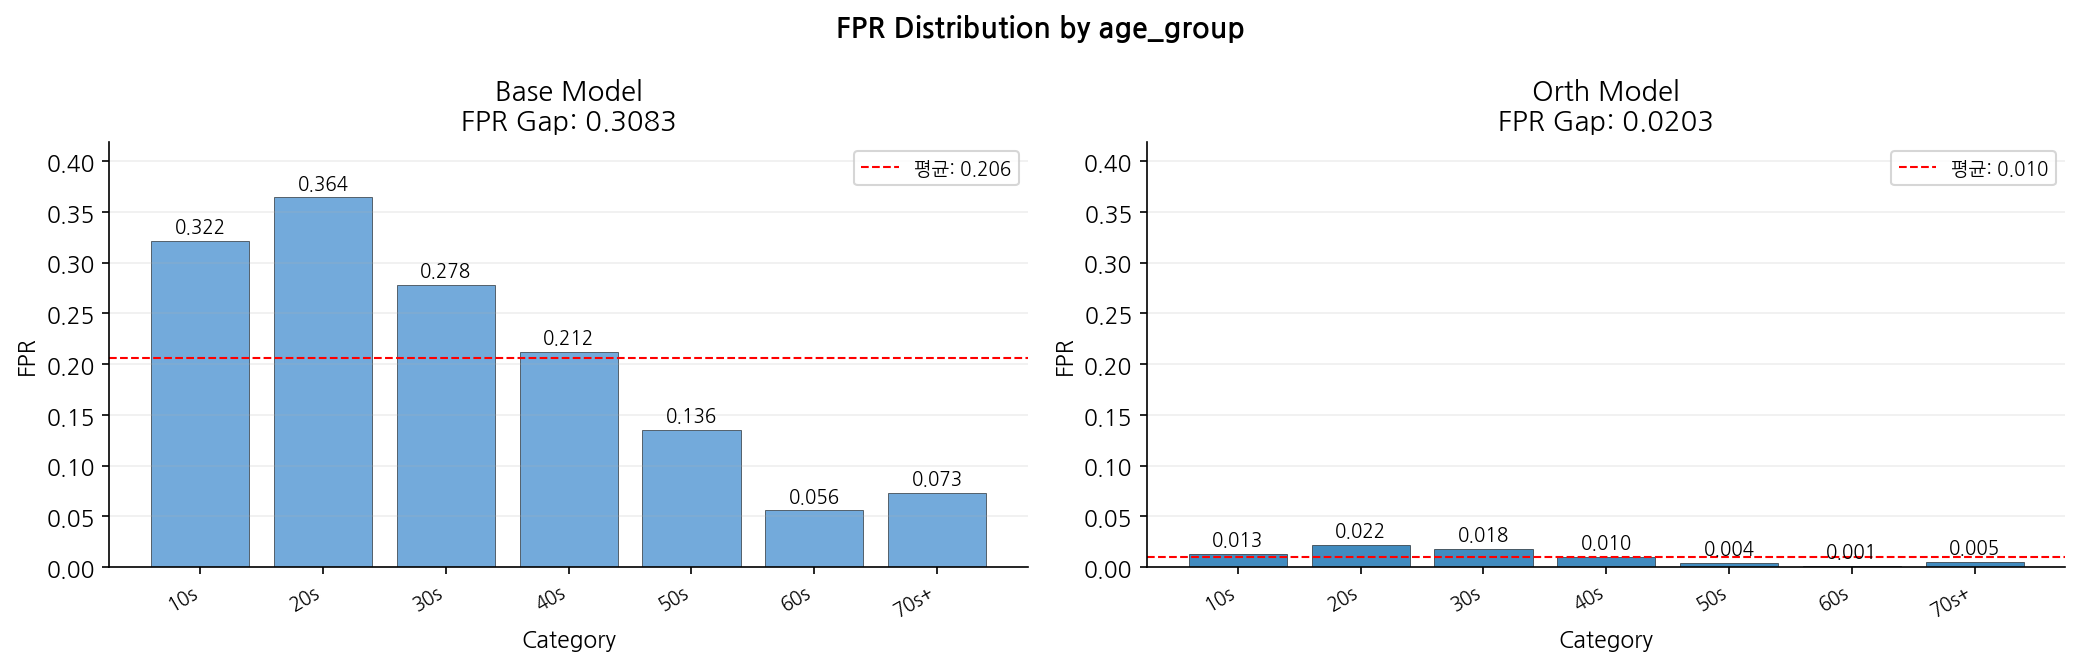

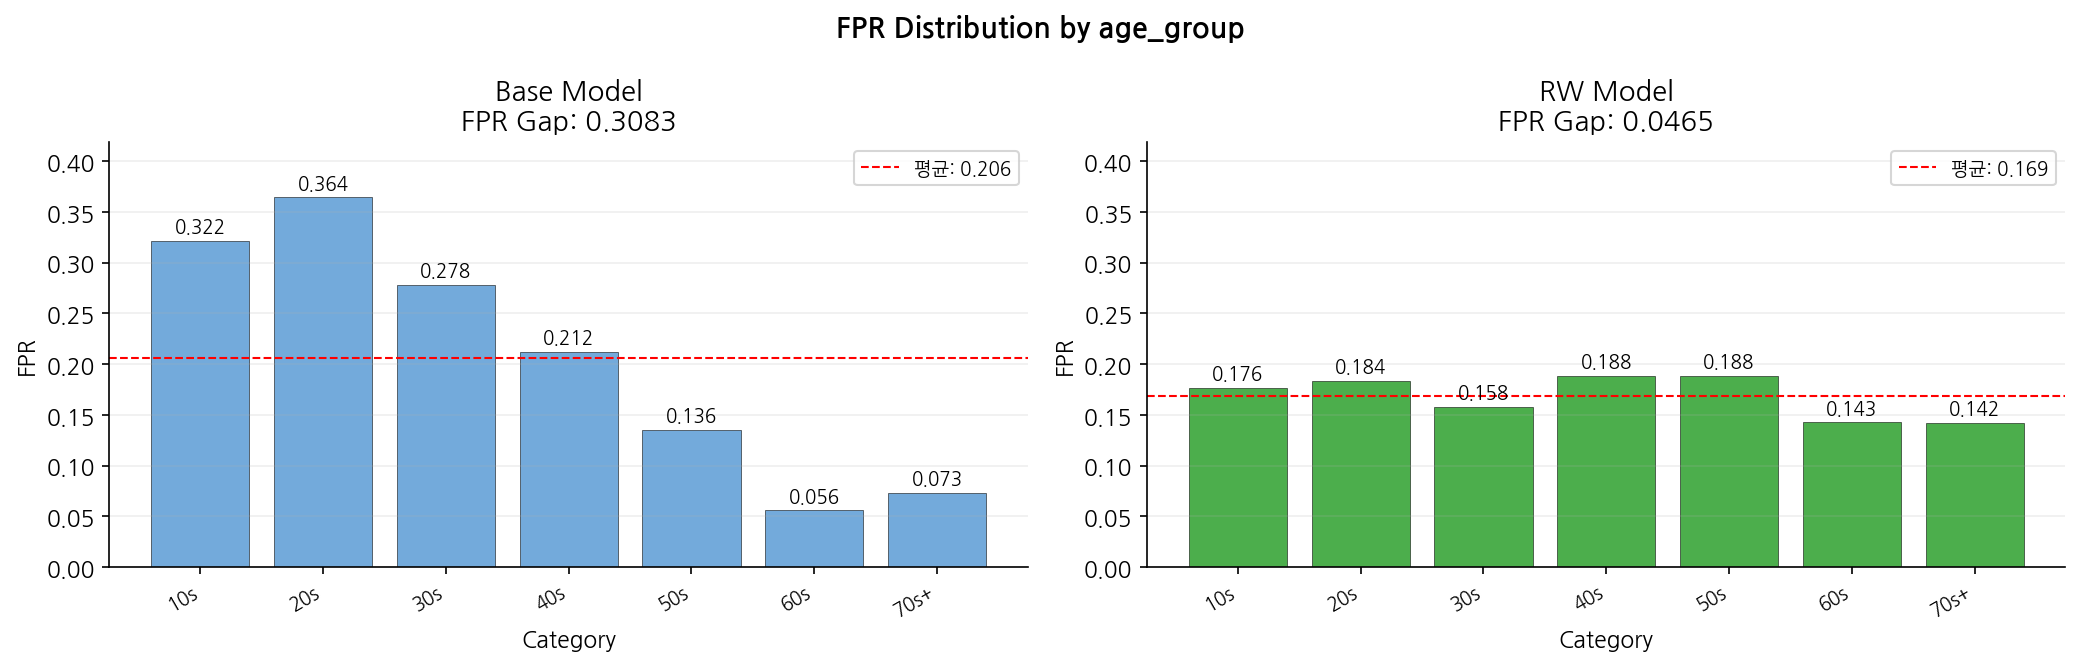

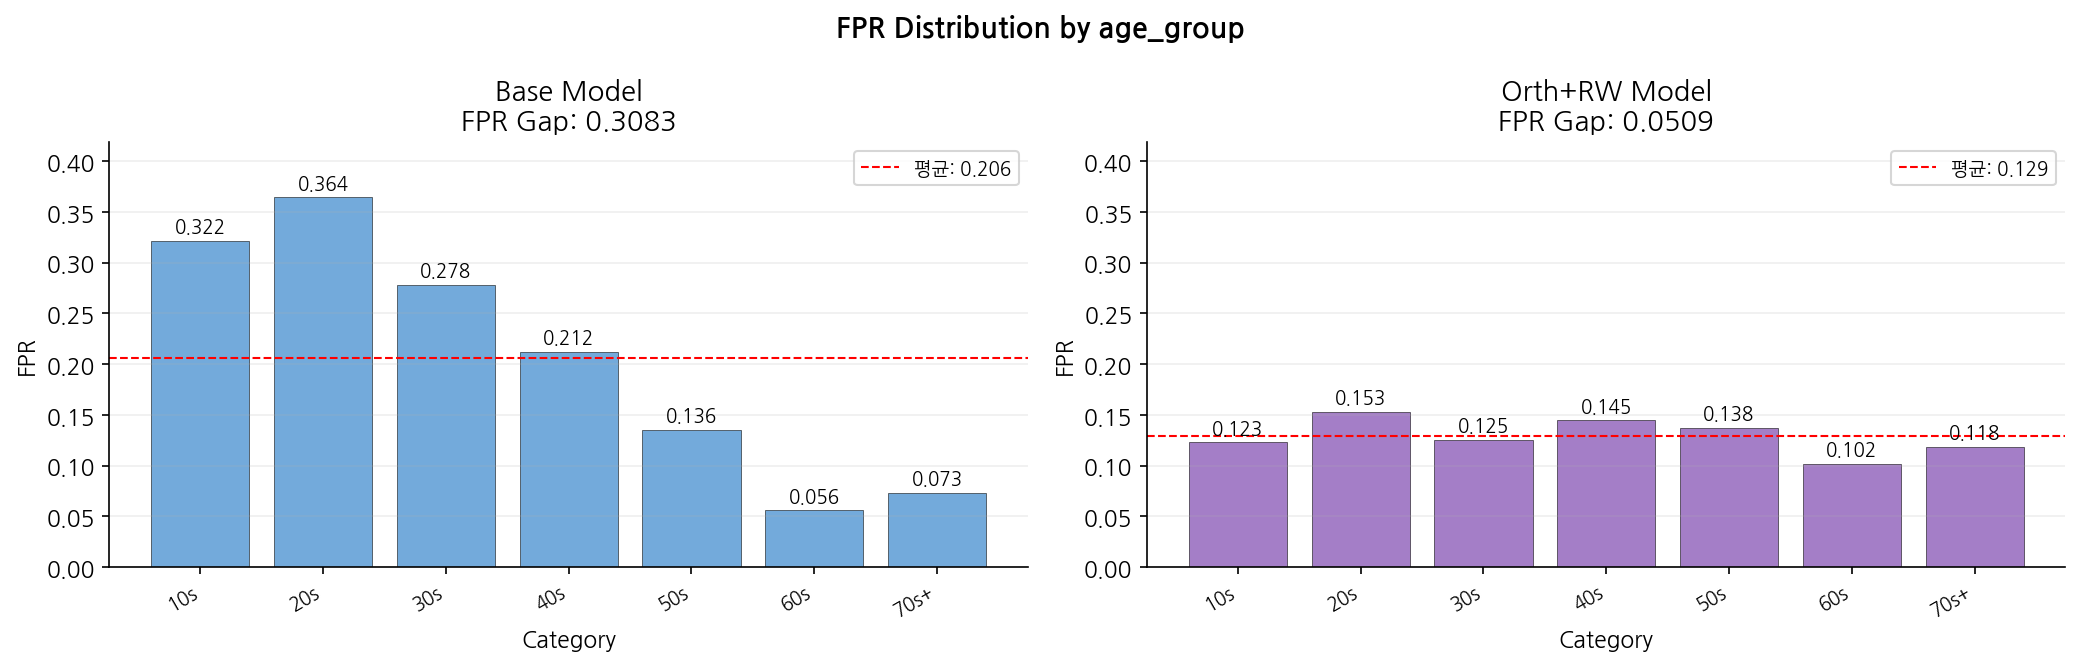

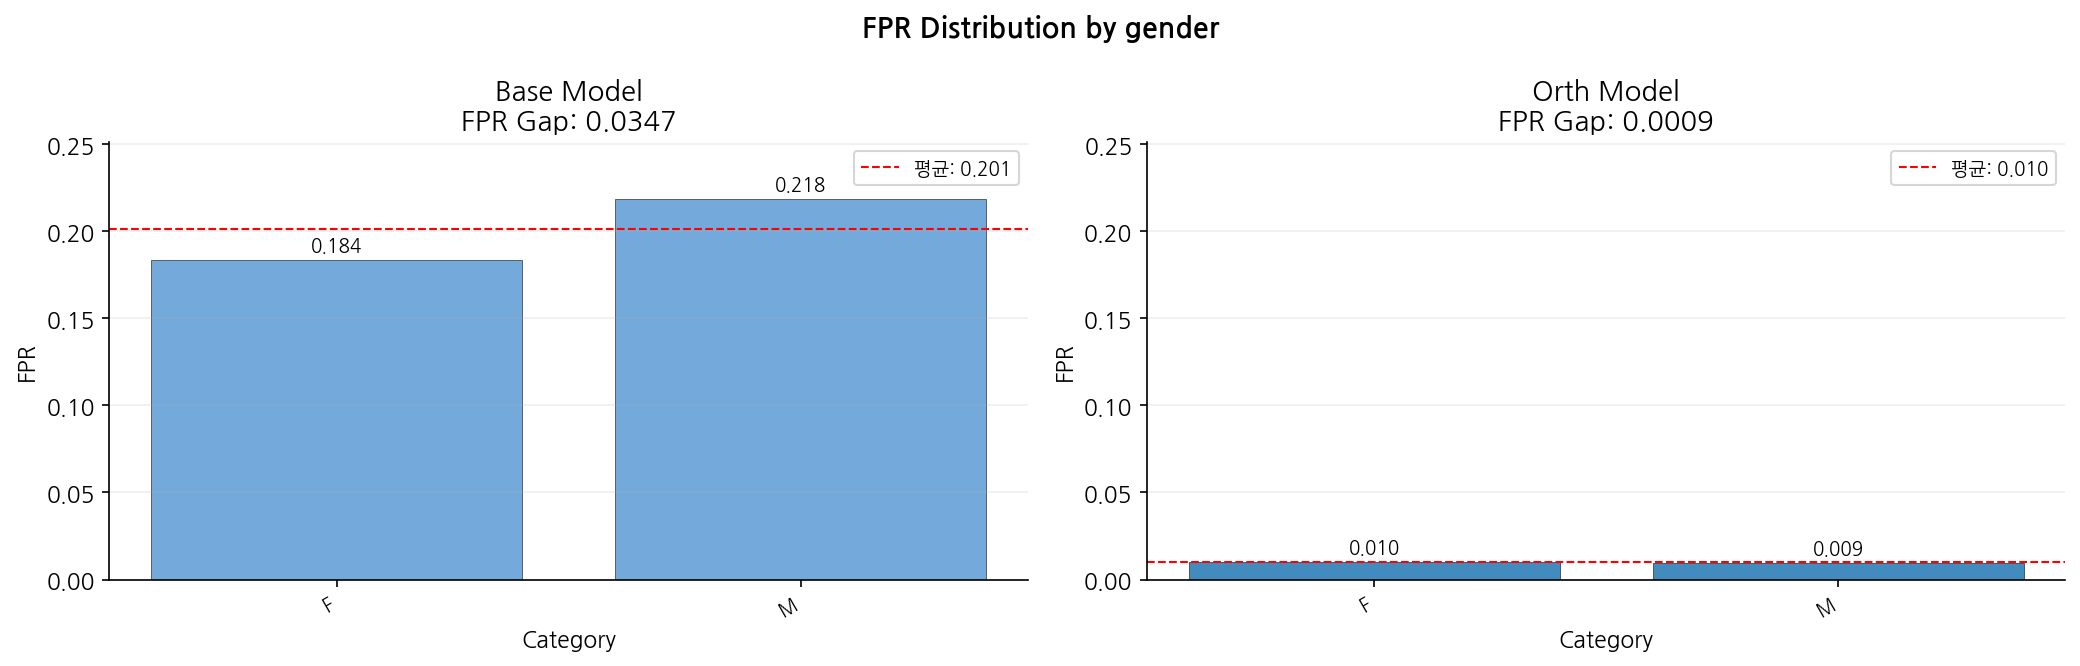

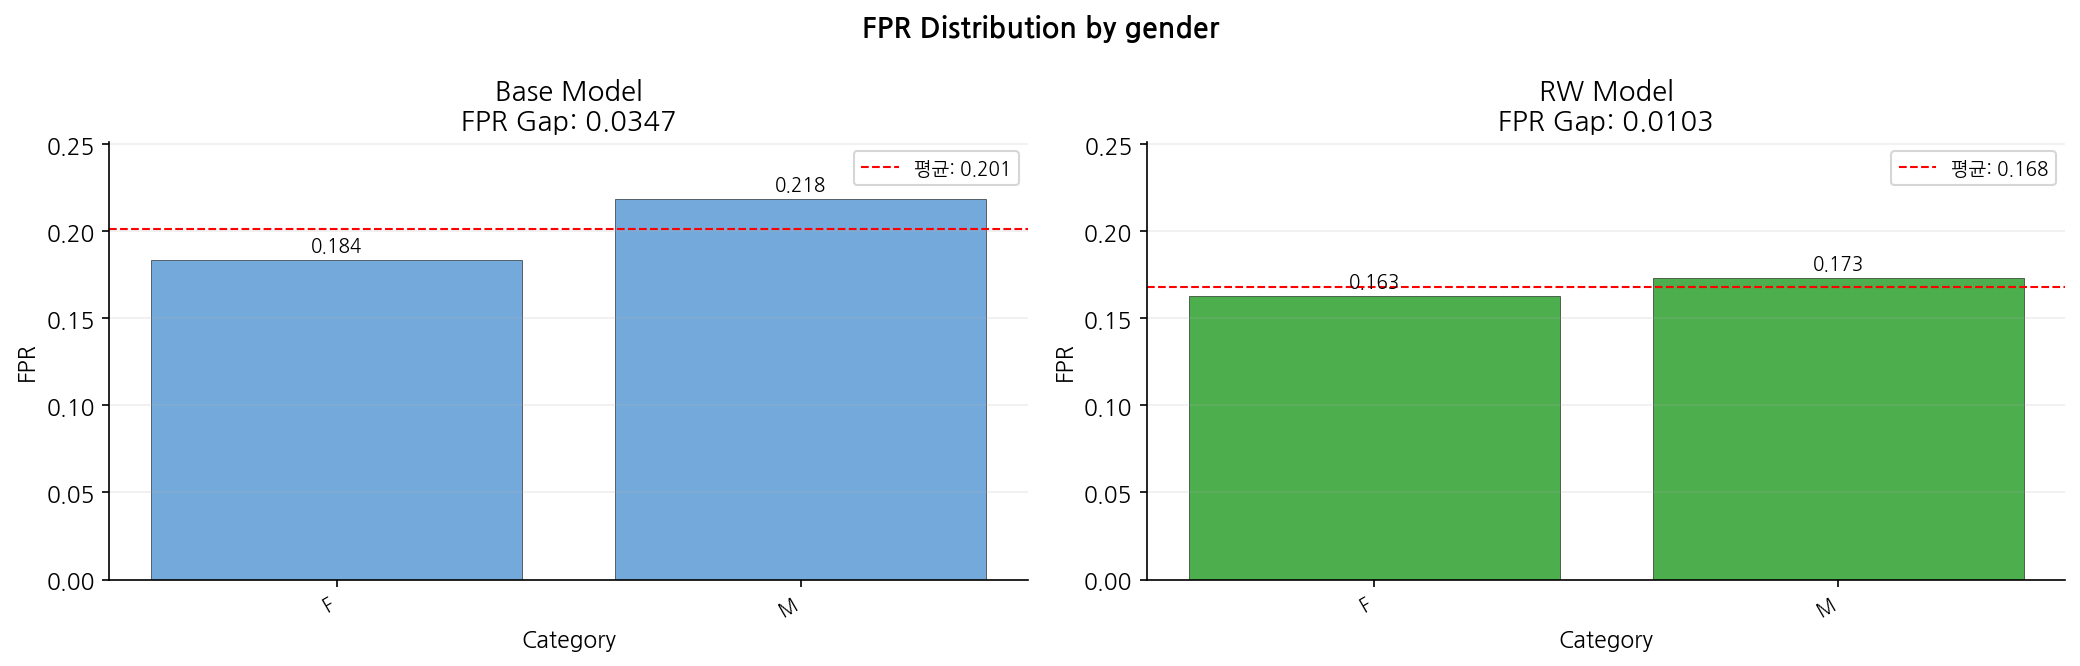

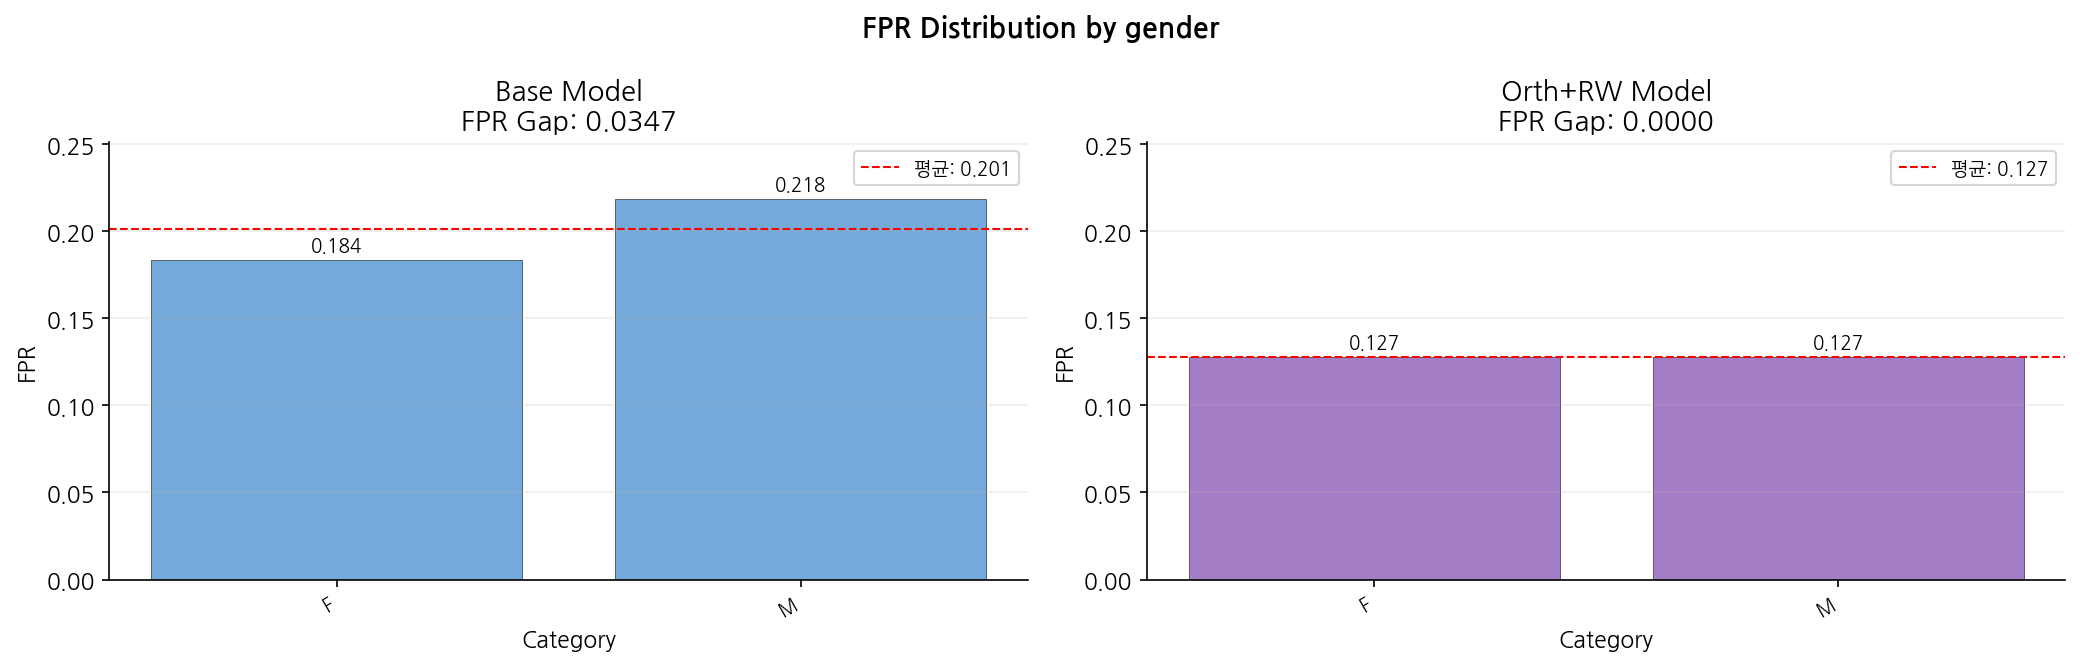

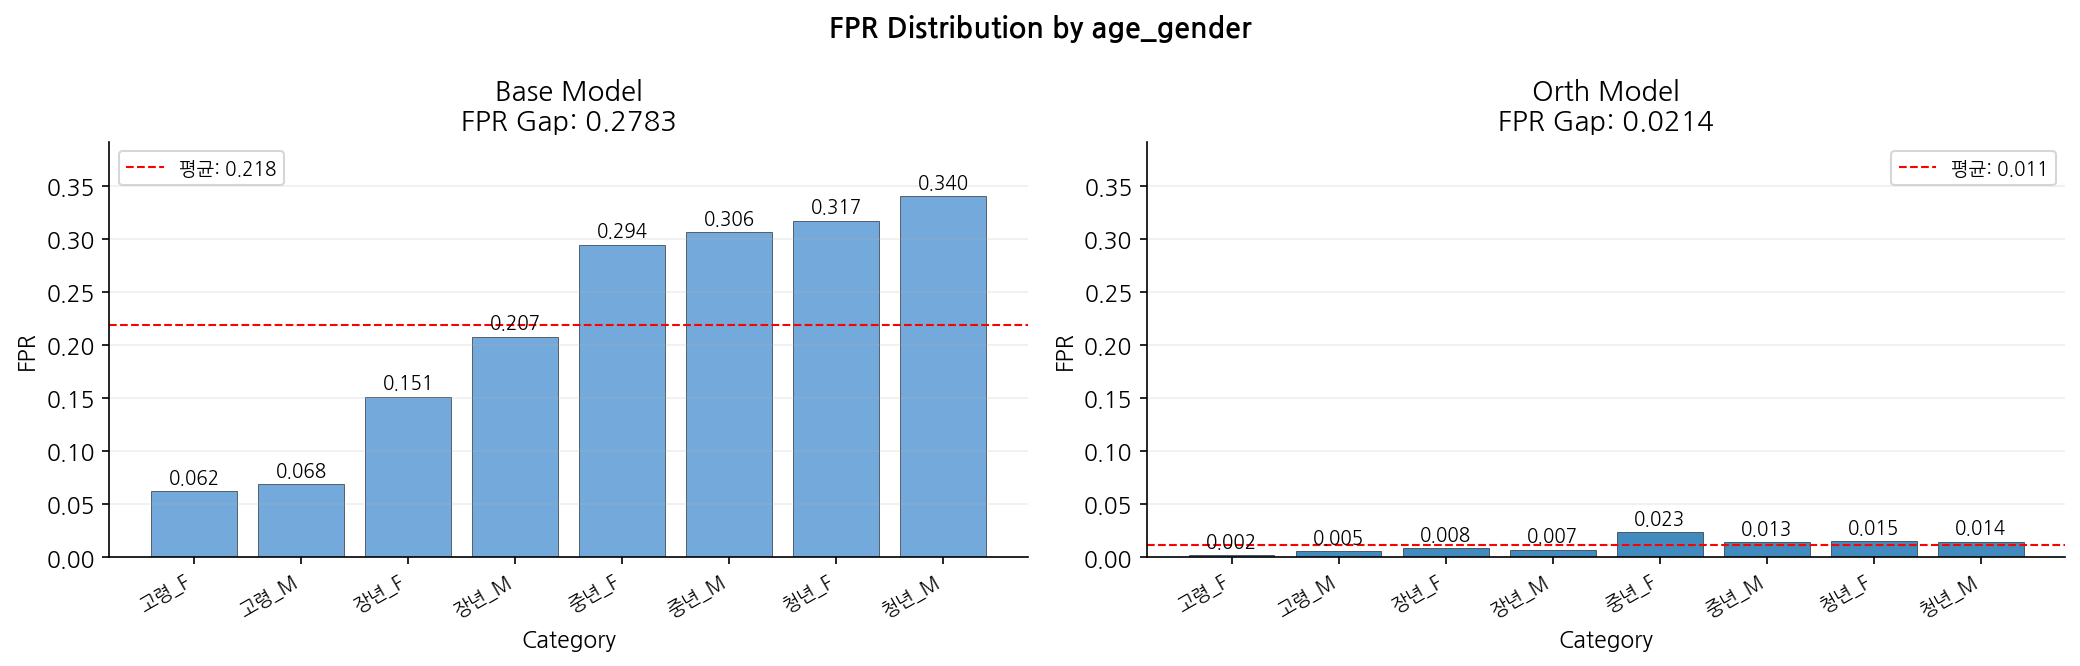

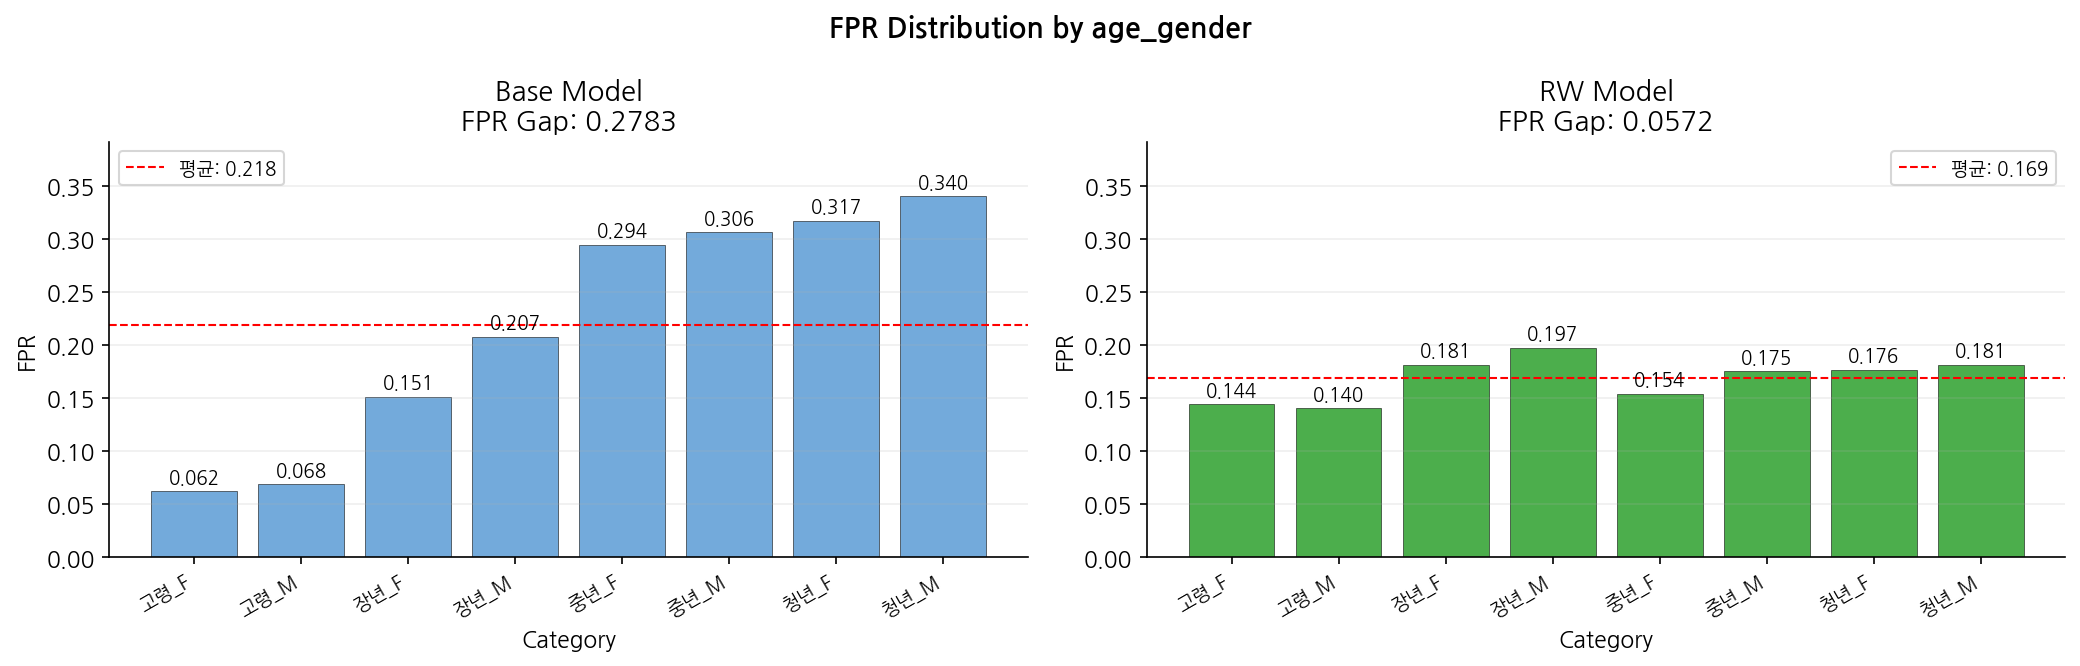

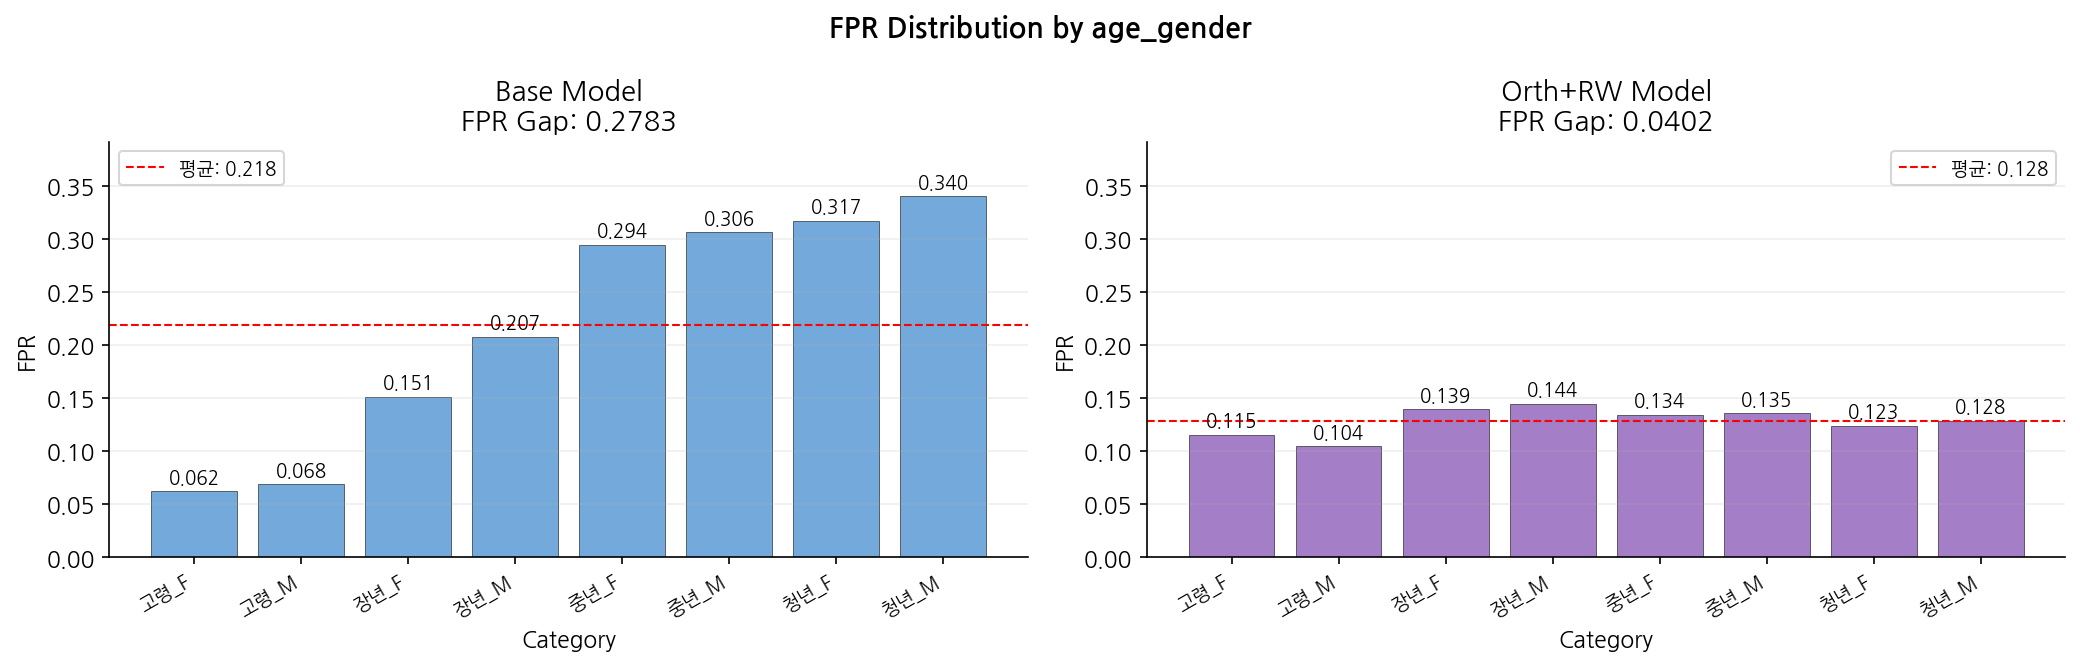

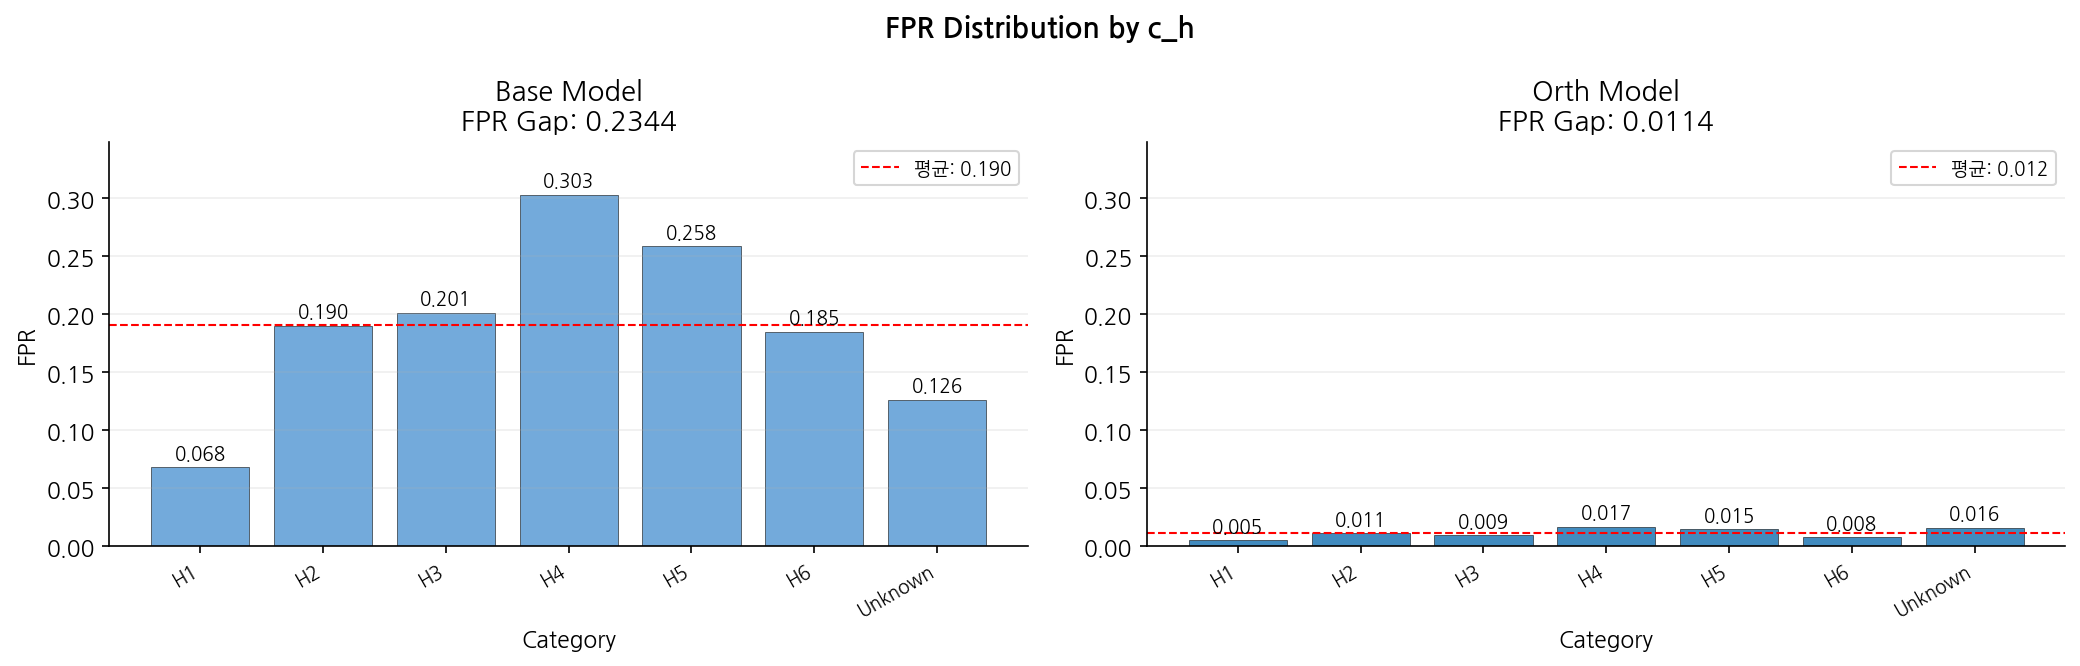

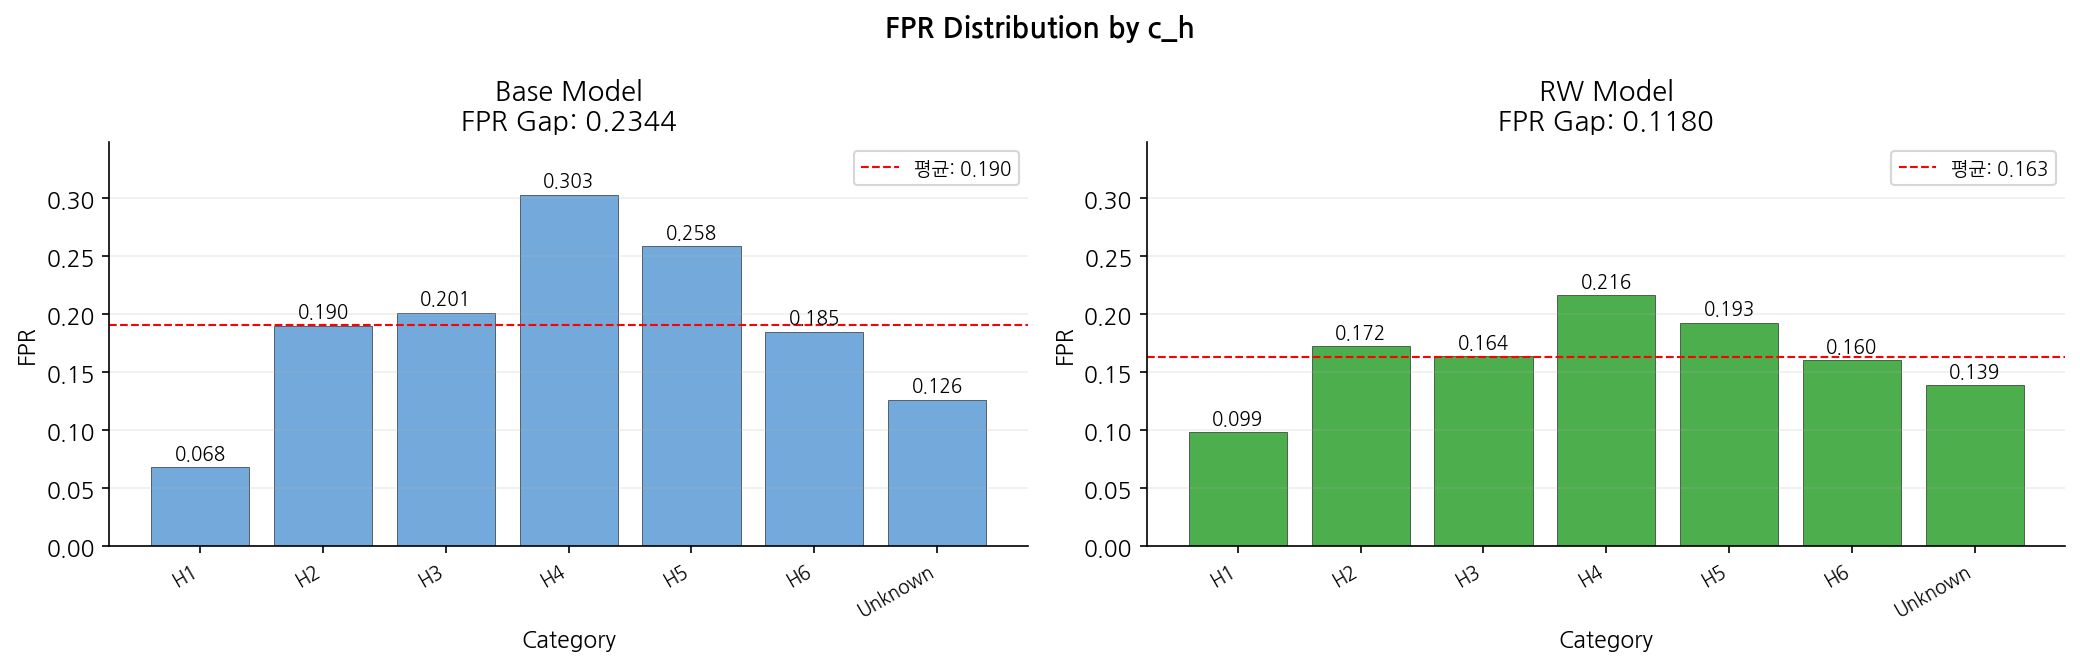

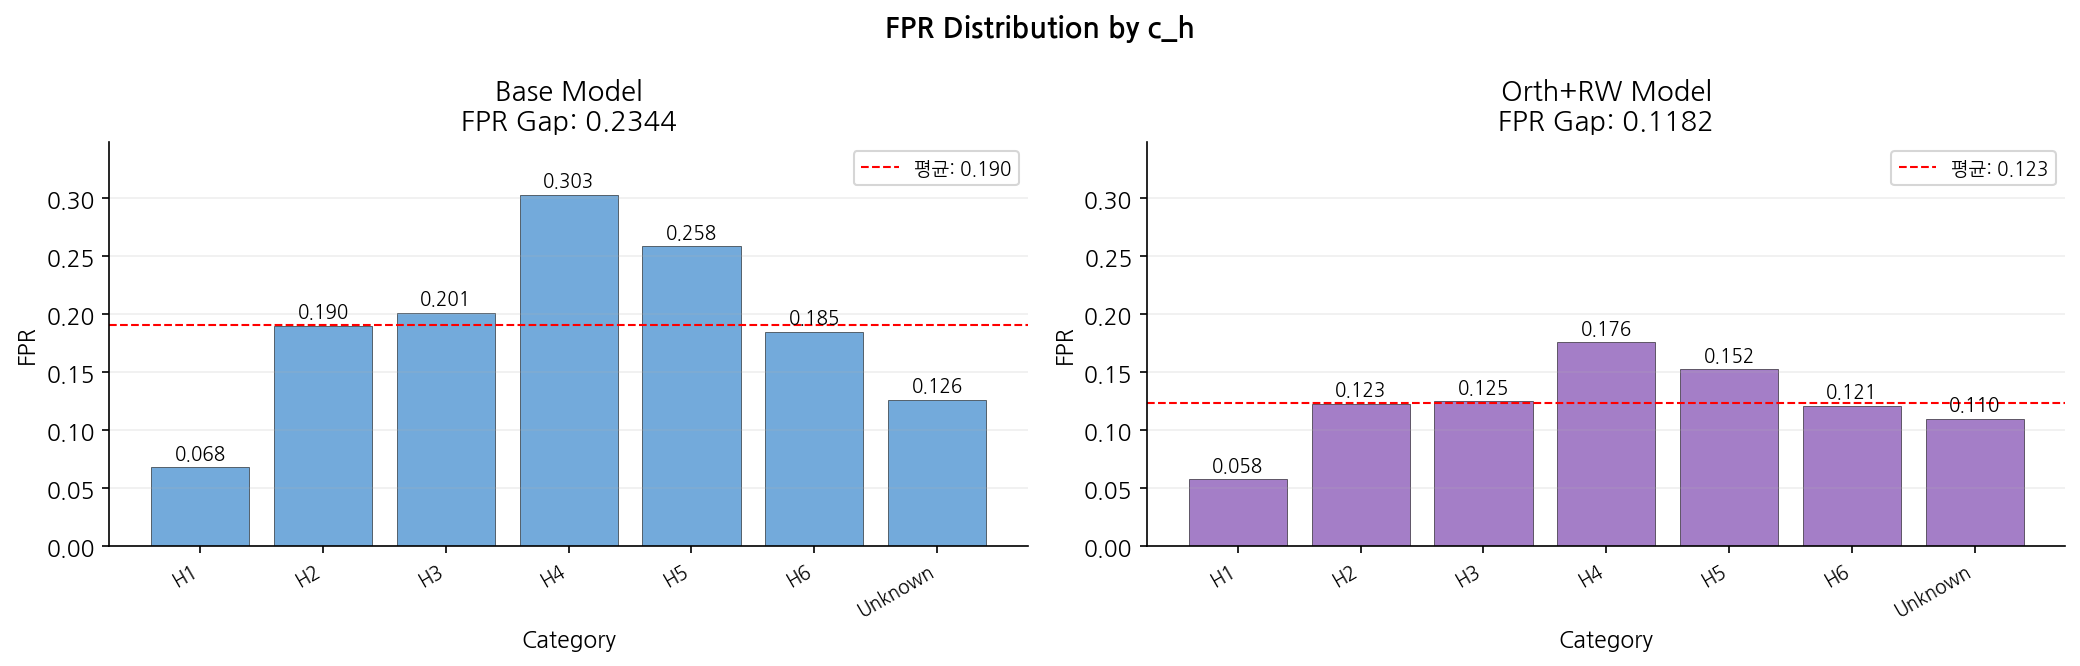

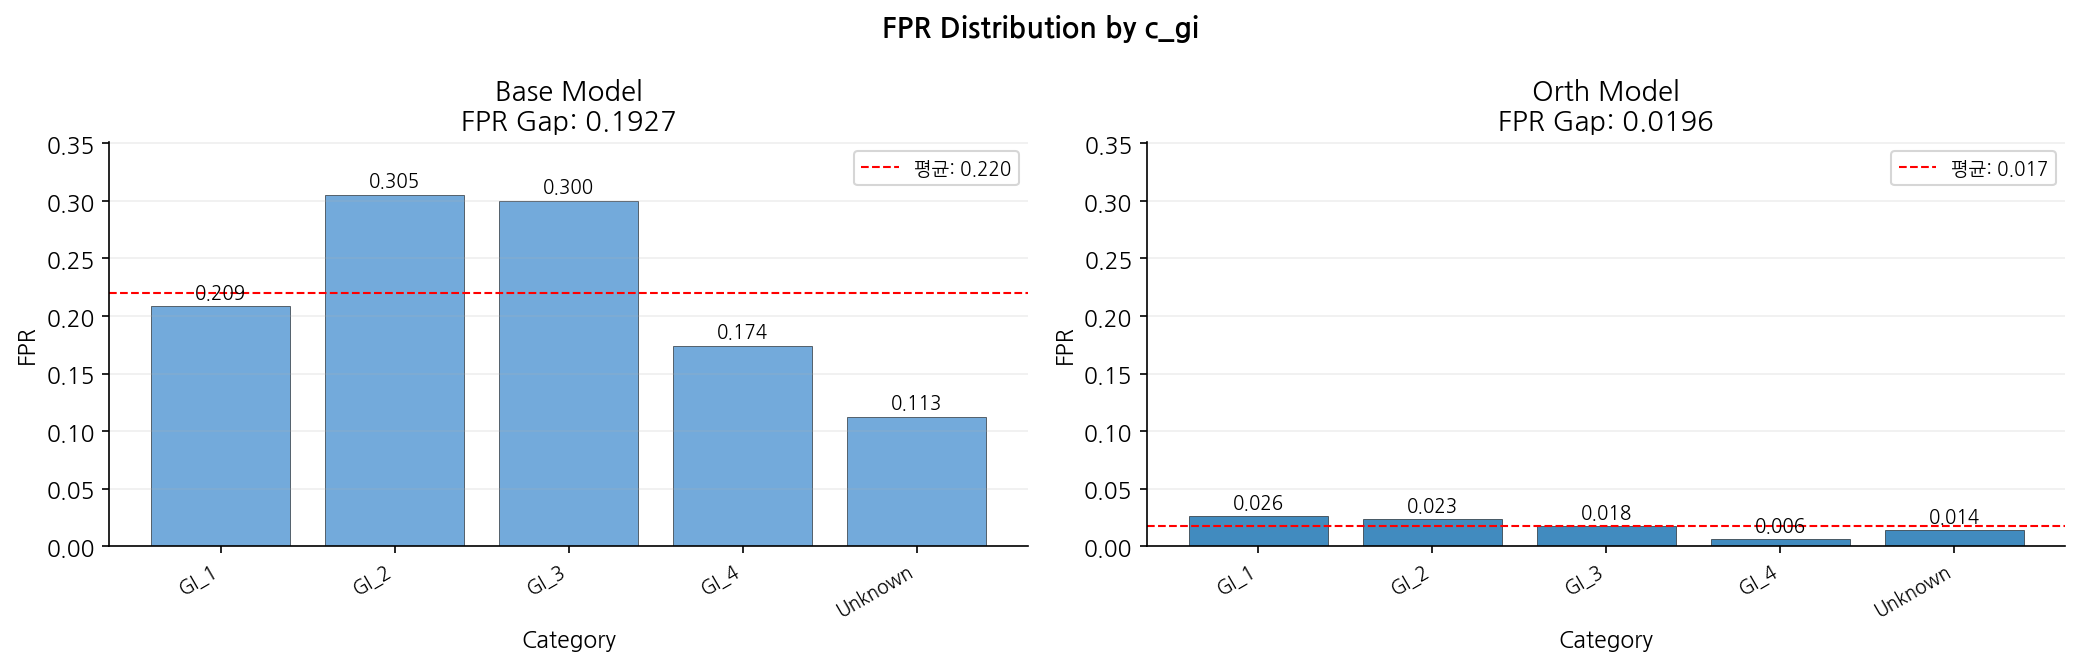

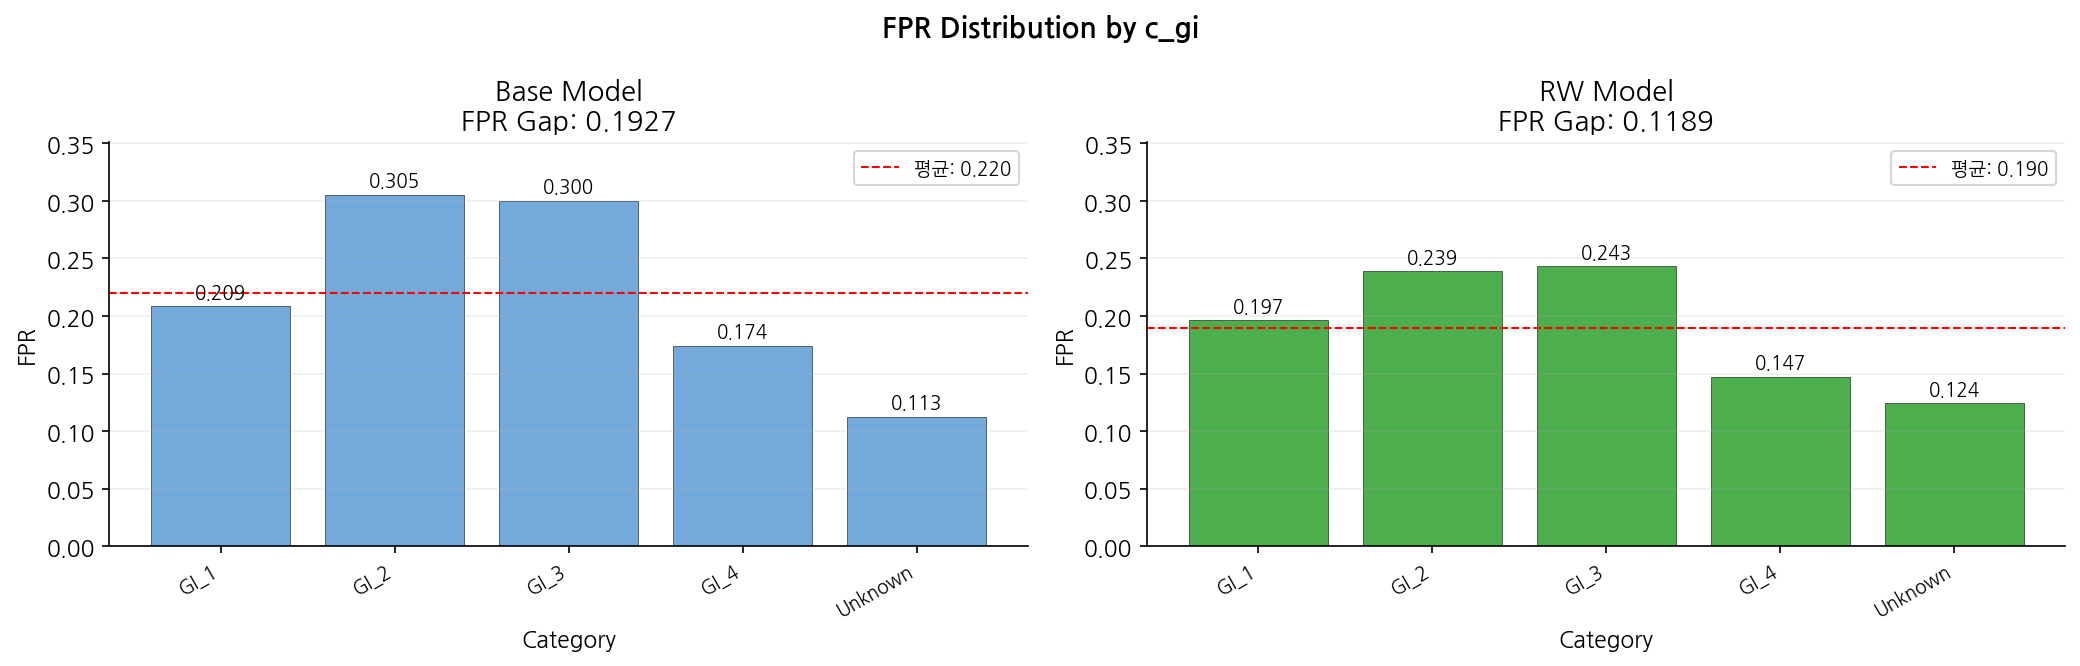

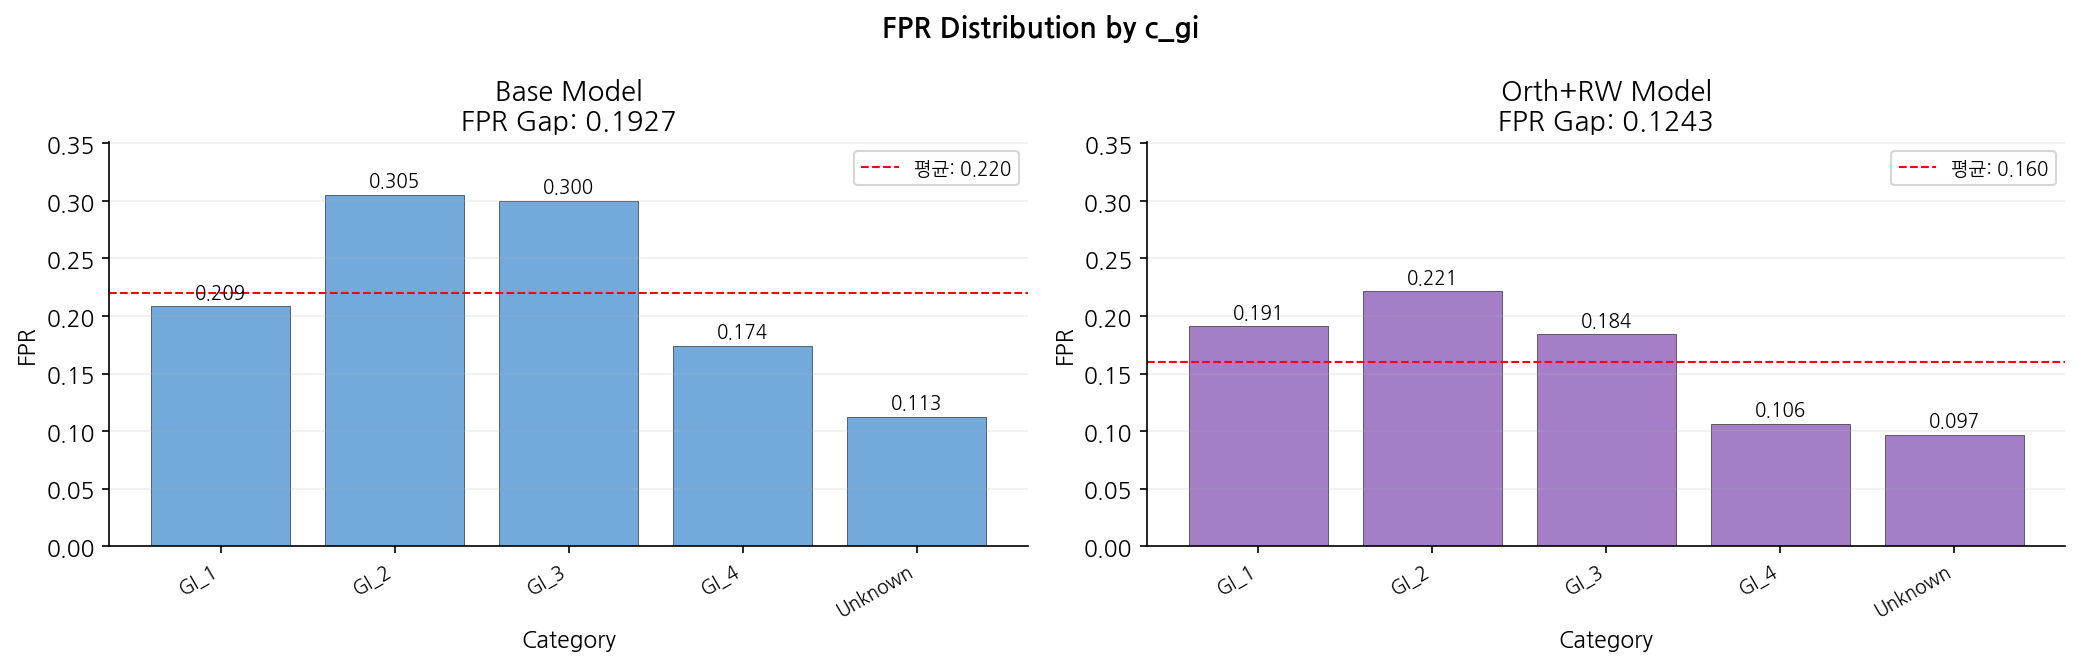

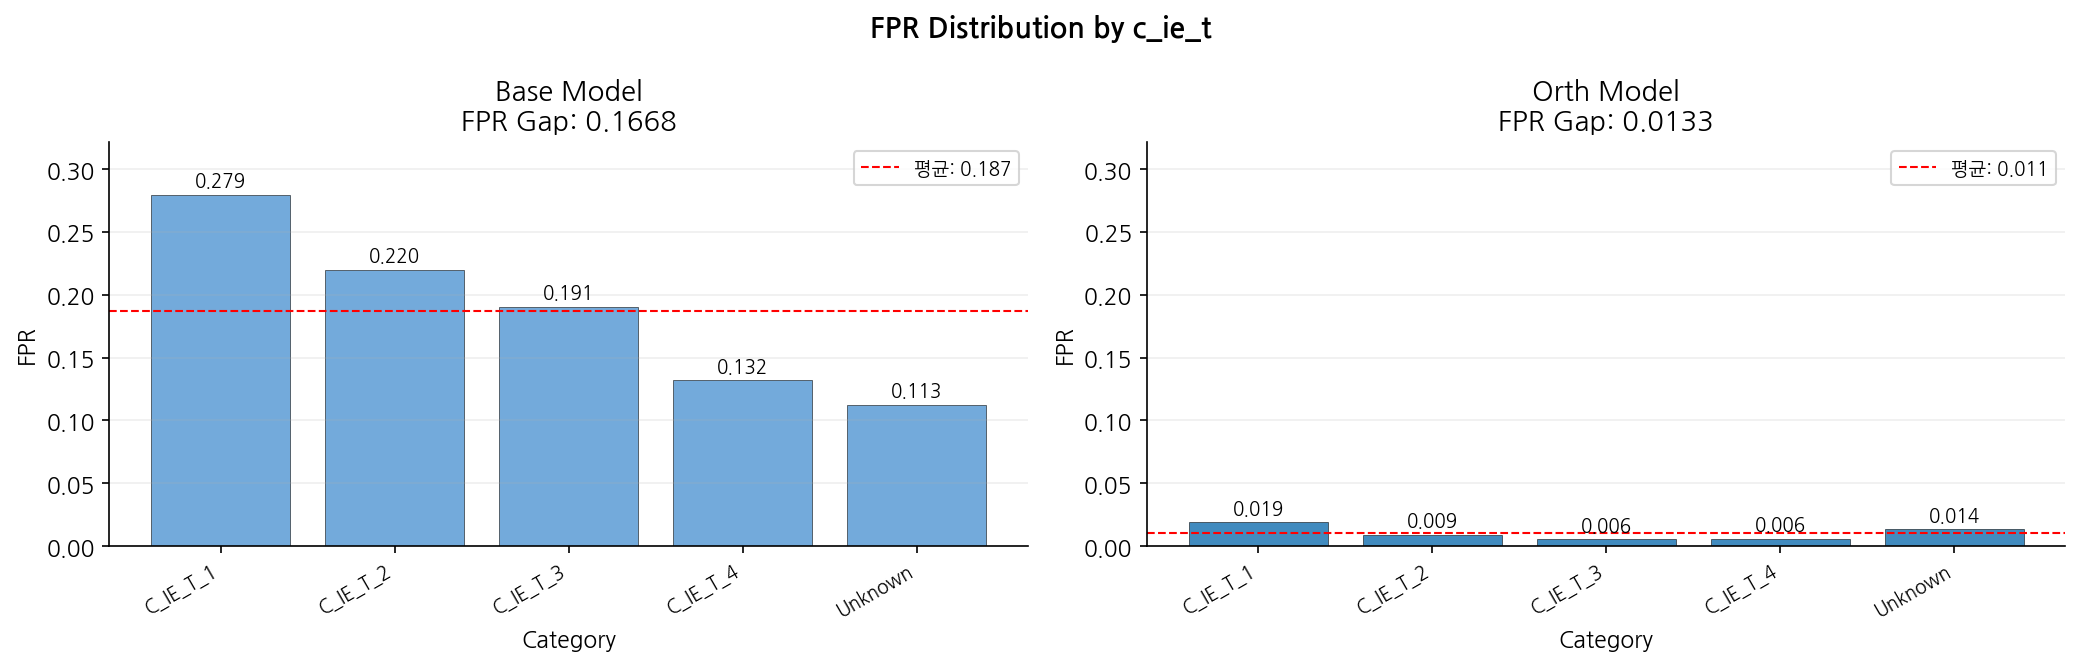

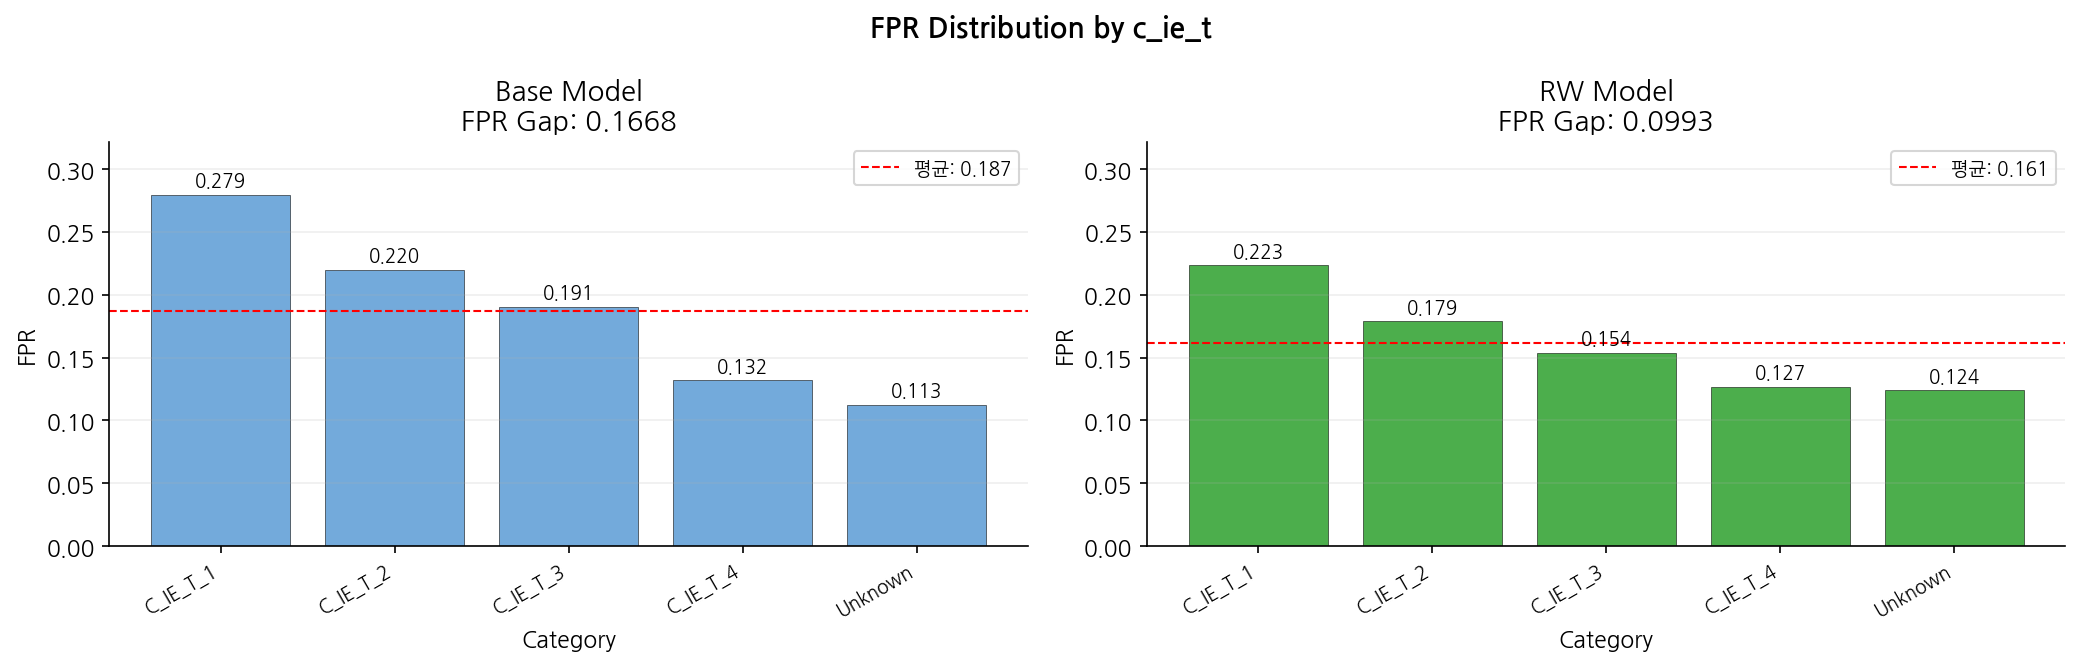

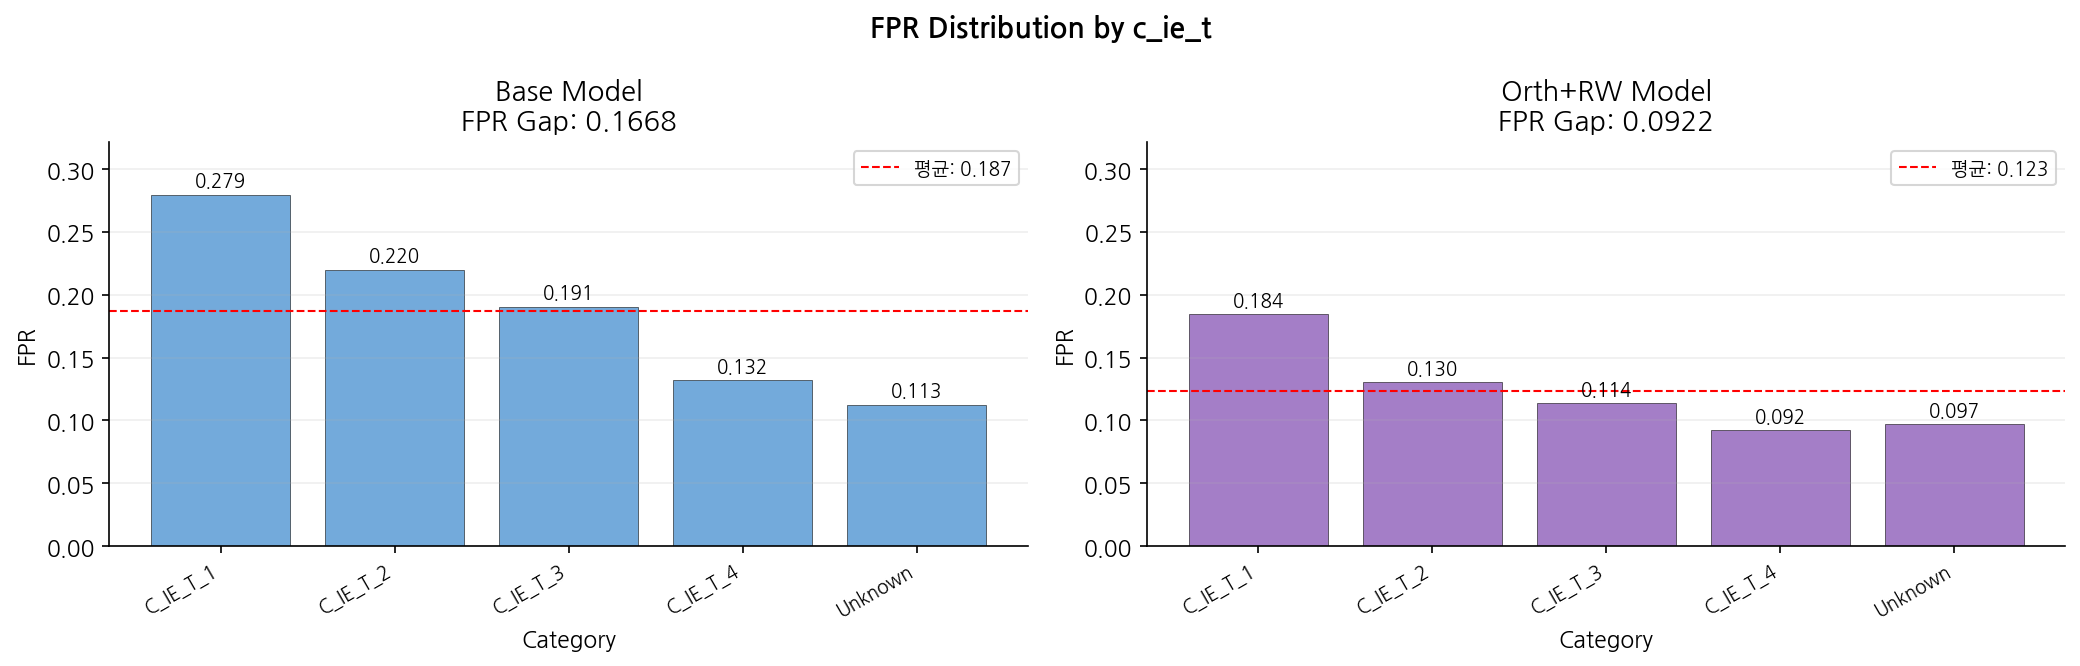

In [19]:
methods_cmp = {'Orth':pred_orth, 'RW':pred_rw, 'Orth+RW':pred_orw}
m_colors = {'Orth':'#1f77b4', 'RW':'#2ca02c', 'Orth+RW':'#9467bd'}

for sn, grps in sensitive_test.items():
    for mn, mpred in methods_cmp.items():
        fb = group_fpr_dict(y_test, pred_base, grps)
        fm = group_fpr_dict(y_test, mpred, grps)
        labs = sorted(fb.keys())
        if not labs: continue
        bv = [fb.get(g,0) for g in labs]; mv = [fm.get(g,0) for g in labs]
        bg, mg = fpr_gap(fb), fpr_gap(fm)
        ymax = min(1.05, max(bv+mv)*1.15)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
        fig.suptitle(f'FPR Distribution by {sn}', fontsize=14, fontweight='bold')

        for ax, vals, gap_v, title, color, mean_v in [
            (axes[0], bv, bg, 'Base Model', '#5b9bd5', np.mean(bv)),
            (axes[1], mv, mg, f'{mn} Model', m_colors[mn], np.mean(mv))]:
            ax.bar(range(len(labs)), vals, color=color, edgecolor='k', linewidth=0.3, alpha=0.85)
            ax.axhline(mean_v, color='red', ls='--', lw=1, label=f'평균: {mean_v:.3f}')
            for i, v in enumerate(vals): ax.text(i, v+ymax*0.02, f'{v:.3f}', ha='center', fontsize=9)
            ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=30, ha='right', fontsize=9)
            ax.set_ylabel('FPR'); ax.set_title(f'{title}\nFPR Gap: {gap_v:.4f}')
            ax.set_ylim(0, ymax); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.2); ax.set_xlabel('Category')
        plt.tight_layout(); plt.savefig(f'fpr_{sn}_{mn}.png', dpi=200, bbox_inches='tight'); plt.show()


## 14. FPR Gap 히트맵

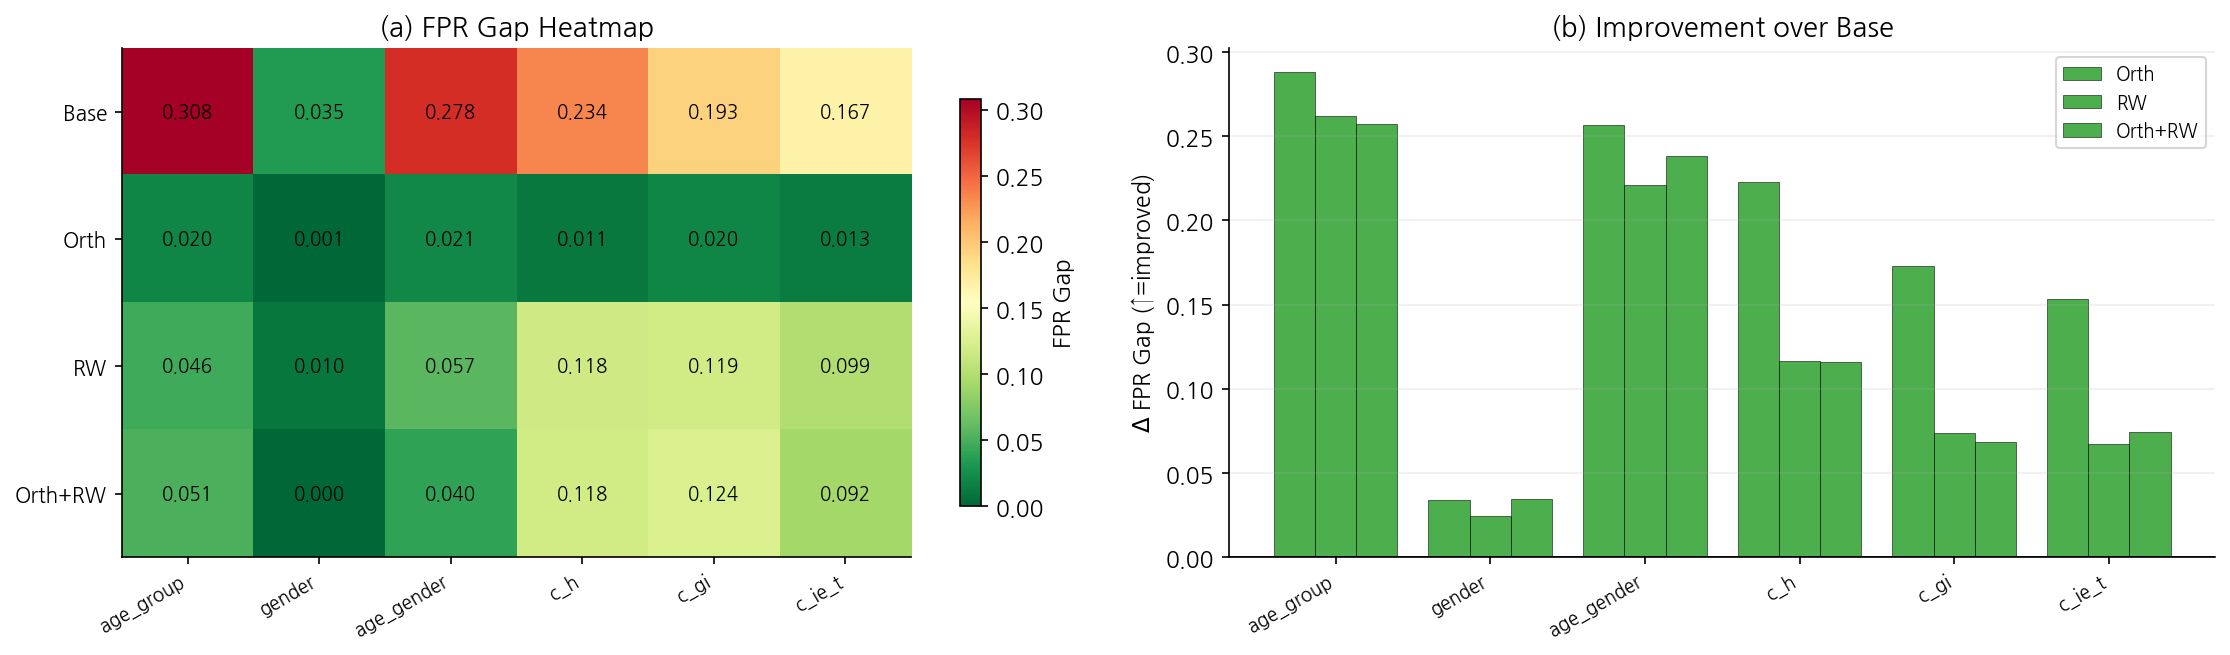

In [20]:
gm = {mn:{s:fpr_gap(group_fpr_dict(y_test,m['pred'],g)) for s,g in sensitive_test.items()} for mn,m in models_eval.items()}
gap_df = pd.DataFrame(gm)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
ax=axes[0]; d=gap_df.values.T.astype(float)
im=ax.imshow(d, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=max(0.01,d.max()))
ax.set_xticks(range(len(gap_df.index))); ax.set_xticklabels(gap_df.index, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(gap_df.columns))); ax.set_yticklabels(gap_df.columns, fontsize=10)
ax.set_title('(a) FPR Gap Heatmap'); plt.colorbar(im, ax=ax, label='FPR Gap', shrink=0.8)
for i in range(len(gap_df.columns)):
    for j in range(len(gap_df.index)):
        ax.text(j, i, f'{d[i,j]:.3f}', ha='center', va='center', fontsize=9, color='black')

ax=axes[1]; dg=gap_df.drop(columns='Base').apply(lambda c: gap_df['Base']-c)
x=np.arange(len(dg.index)); nm=len(dg.columns); w=0.8/nm
for i, col in enumerate(dg.columns):
    cs=['#2ca02c' if v>0 else '#d62728' for v in dg[col]]
    ax.bar(x+i*w, dg[col], w, label=col, color=cs, alpha=0.85, edgecolor='k', linewidth=0.3)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x+w*(nm-1)/2); ax.set_xticklabels(dg.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('$\Delta$ FPR Gap (↑=improved)'); ax.set_title('(b) Improvement over Base')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.2)
plt.tight_layout(); plt.savefig('fpr_gap_analysis.png', dpi=200, bbox_inches='tight'); plt.show()


## 15. 민감변수별 FPR 비교 표

In [20]:
rows = []
for sn, grps in sensitive_test.items():
    for g in sorted(grps.dropna().unique()):
        mask=(grps==g).values
        if mask.sum()<10: continue
        yt=np.array(y_test)[mask]
        if len(np.unique(yt))<2: continue
        row={'민감변수':sn,'그룹':g}
        for mn,m in models_eval.items():
            yp=np.array(m['pred'])[mask]; tn,fp,_,_=confusion_matrix(yt,yp,labels=[0,1]).ravel()
            row[mn]=round(fp/(fp+tn),4)
        rows.append(row)
    gr={'민감변수':sn,'그룹':'▶ Gap'}
    for mn in models_eval:
        vs=[r[mn] for r in rows if r['민감변수']==sn and r['그룹']!='▶ Gap']
        gr[mn]=round(max(vs)-min(vs),4) if vs else 0
    rows.append(gr)

ft=pd.DataFrame(rows).set_index(['민감변수','그룹'])
def sf(df):
    def _h(s):
        return ['background-color:#d4edda;font-weight:bold;color:black' if idx[1]=='▶ Gap' and val==df.loc[(idx[0],'▶ Gap')].min()
                else 'font-weight:bold;color:black' if idx[1]=='▶ Gap' else 'color:black' for idx,val in s.items()]
    def _b(df):
        st=pd.DataFrame('',index=df.index,columns=df.columns); st['Base']='background-color:#fff3cd;color:black'; return st
    return df.style.apply(_h).apply(_b,axis=None).format('{:.4f}').set_caption("민감변수별 FPR | Base | Gap최소").set_table_styles([
        {'selector':'th','props':[('background-color','#2c3e50'),('color','white'),('text-align','center')]},
        {'selector':'td','props':[('text-align','center'),('padding','5px'),('color','black')]}])
display(sf(ft))


저장: fpr_comparison_age.png


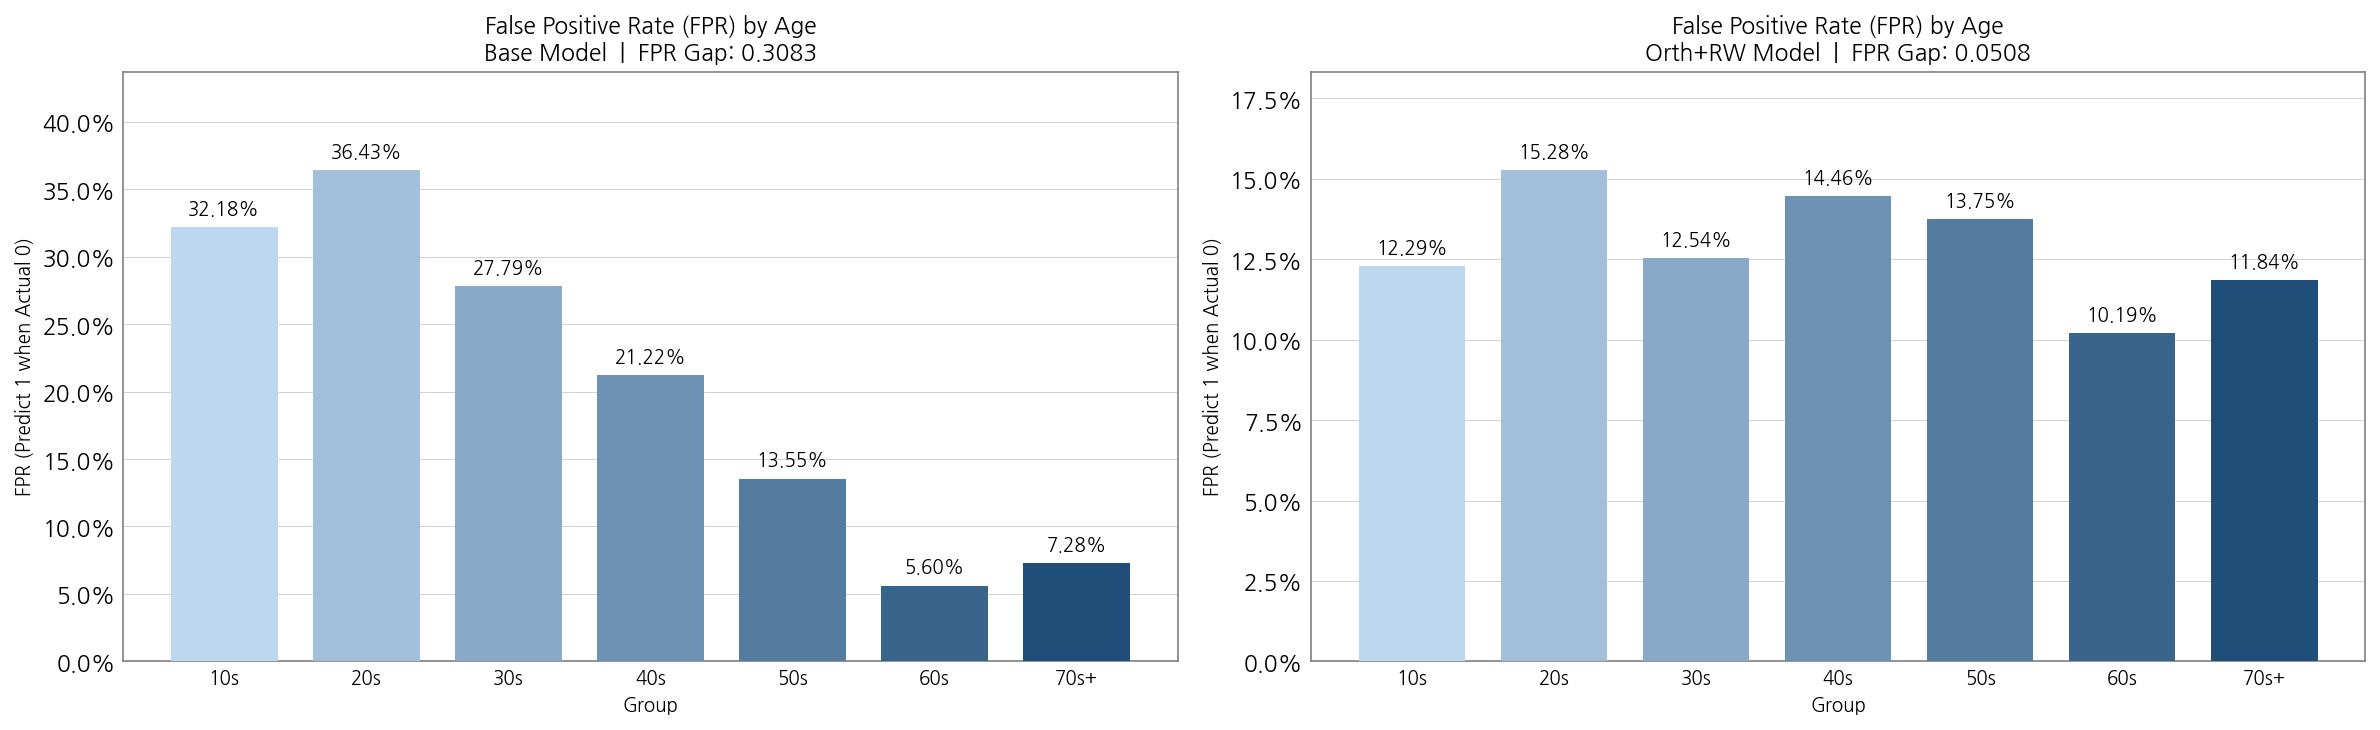

저장: fpr_comparison_gender.png


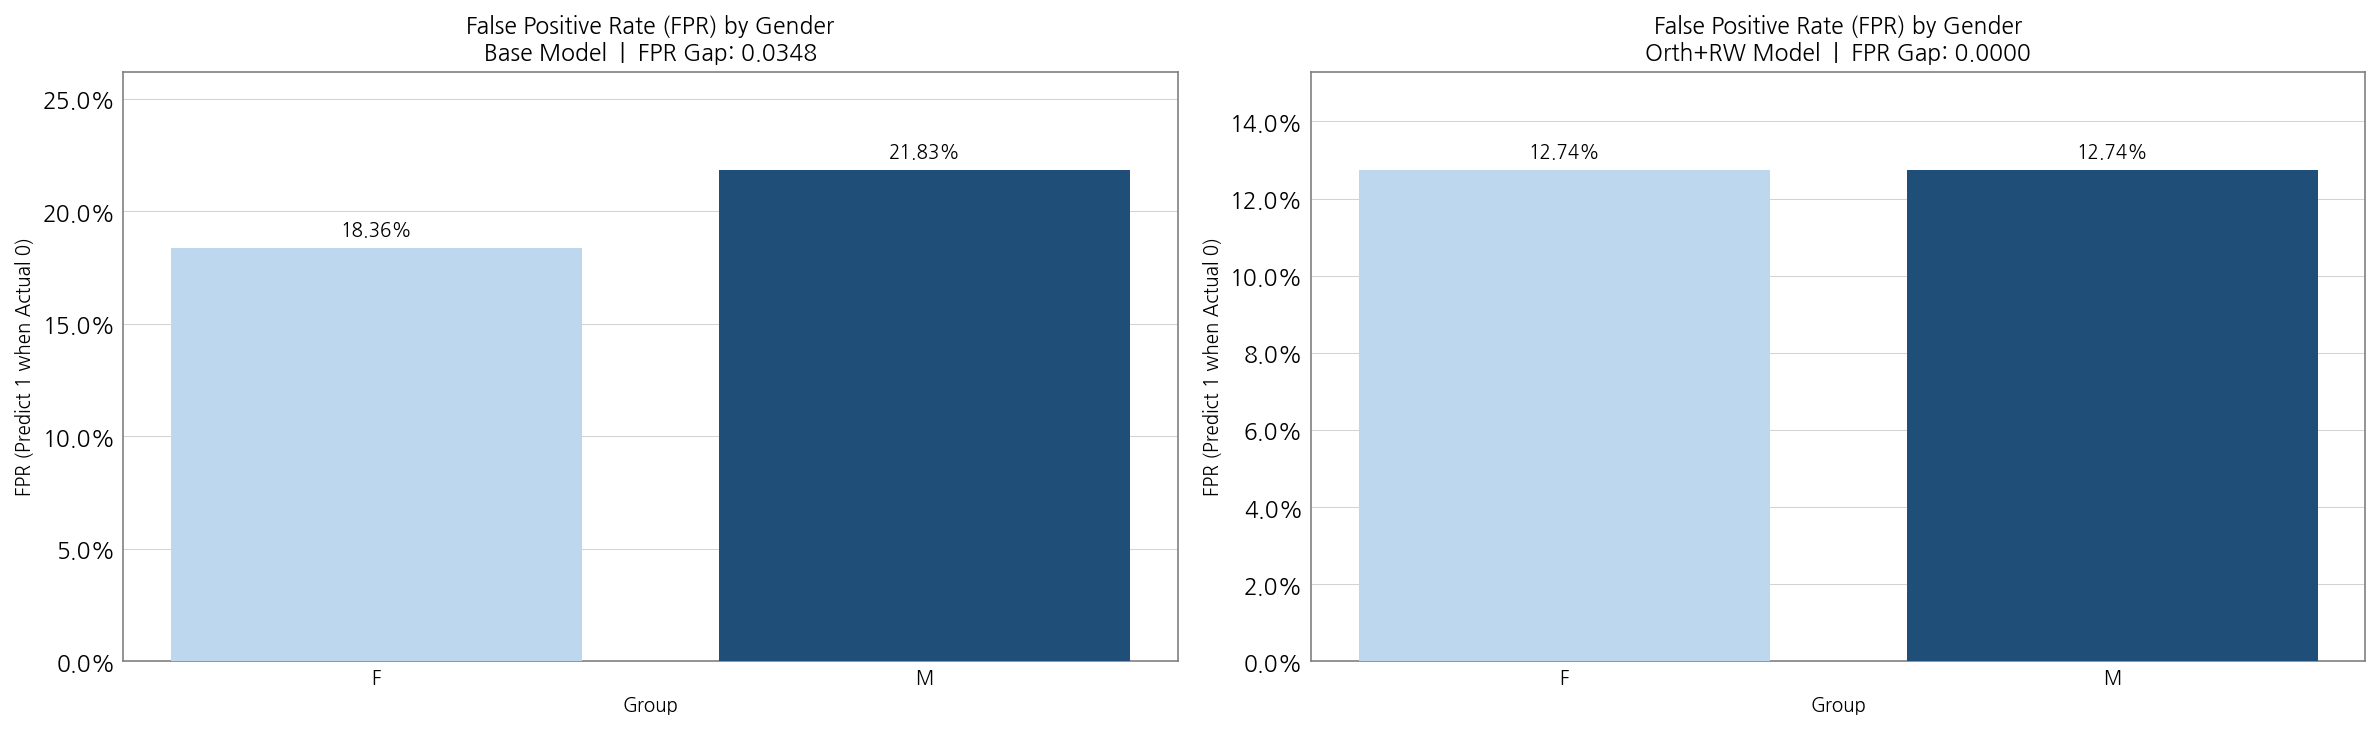

저장: fpr_comparison_age_gender.png


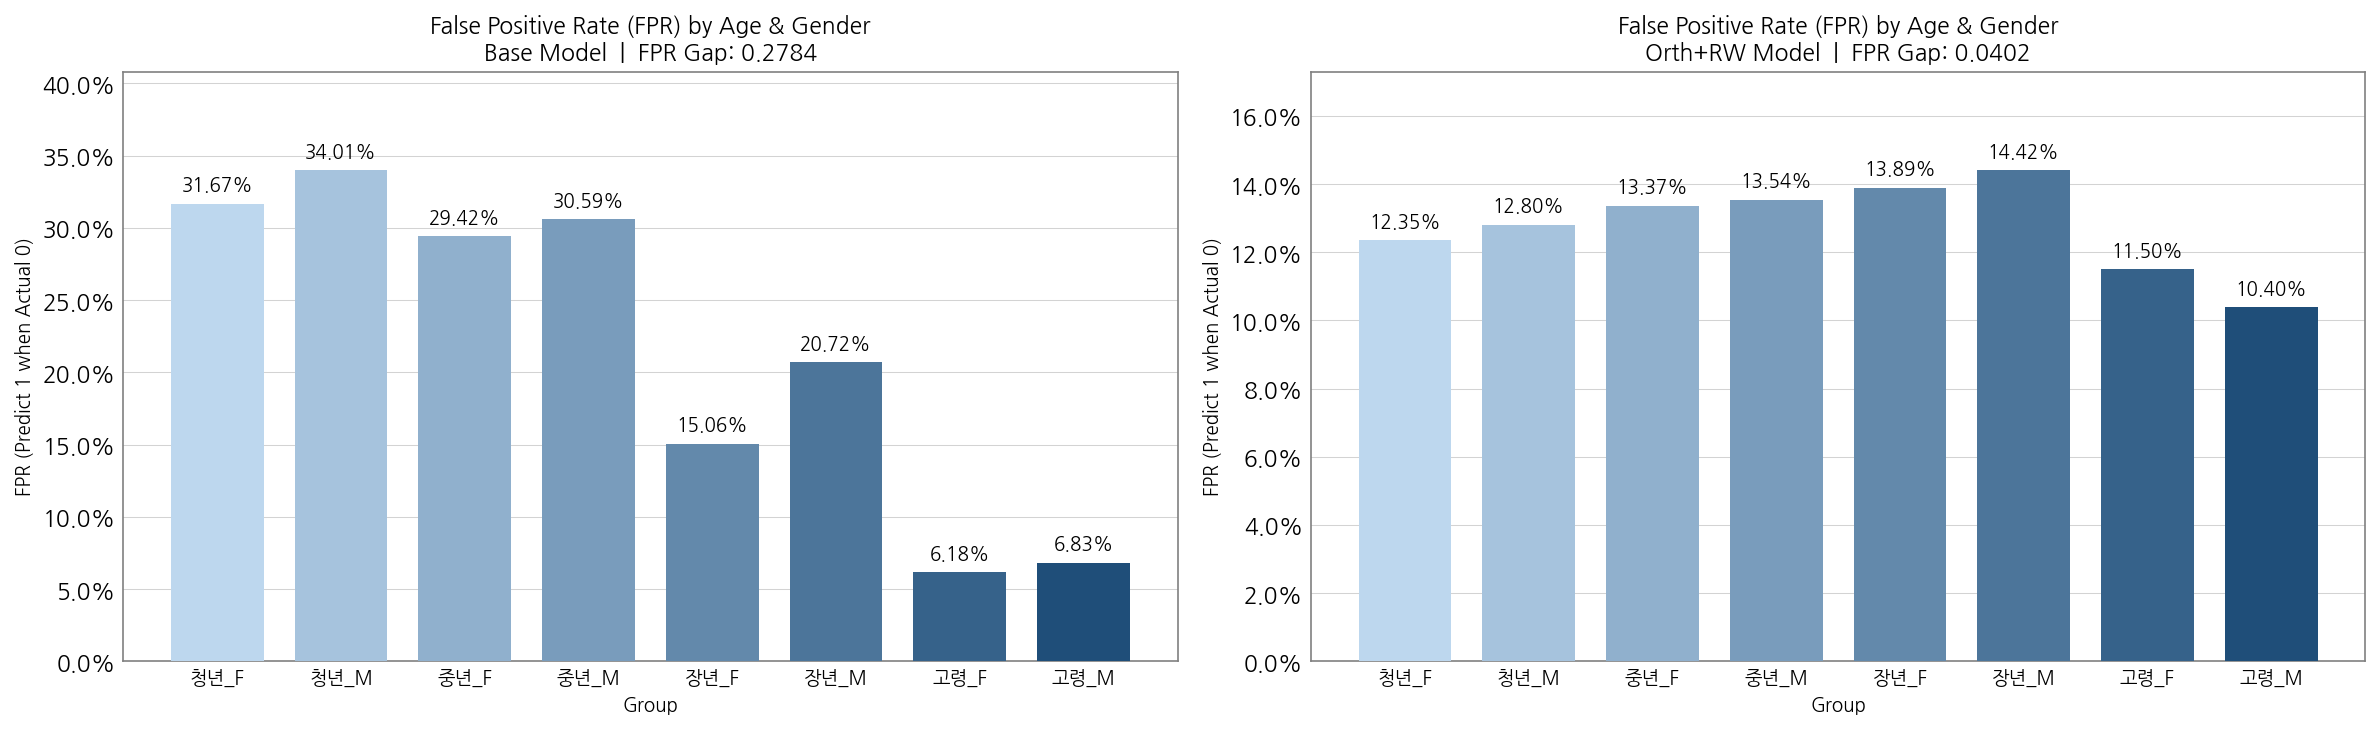

저장: fpr_comparison_c_h.png


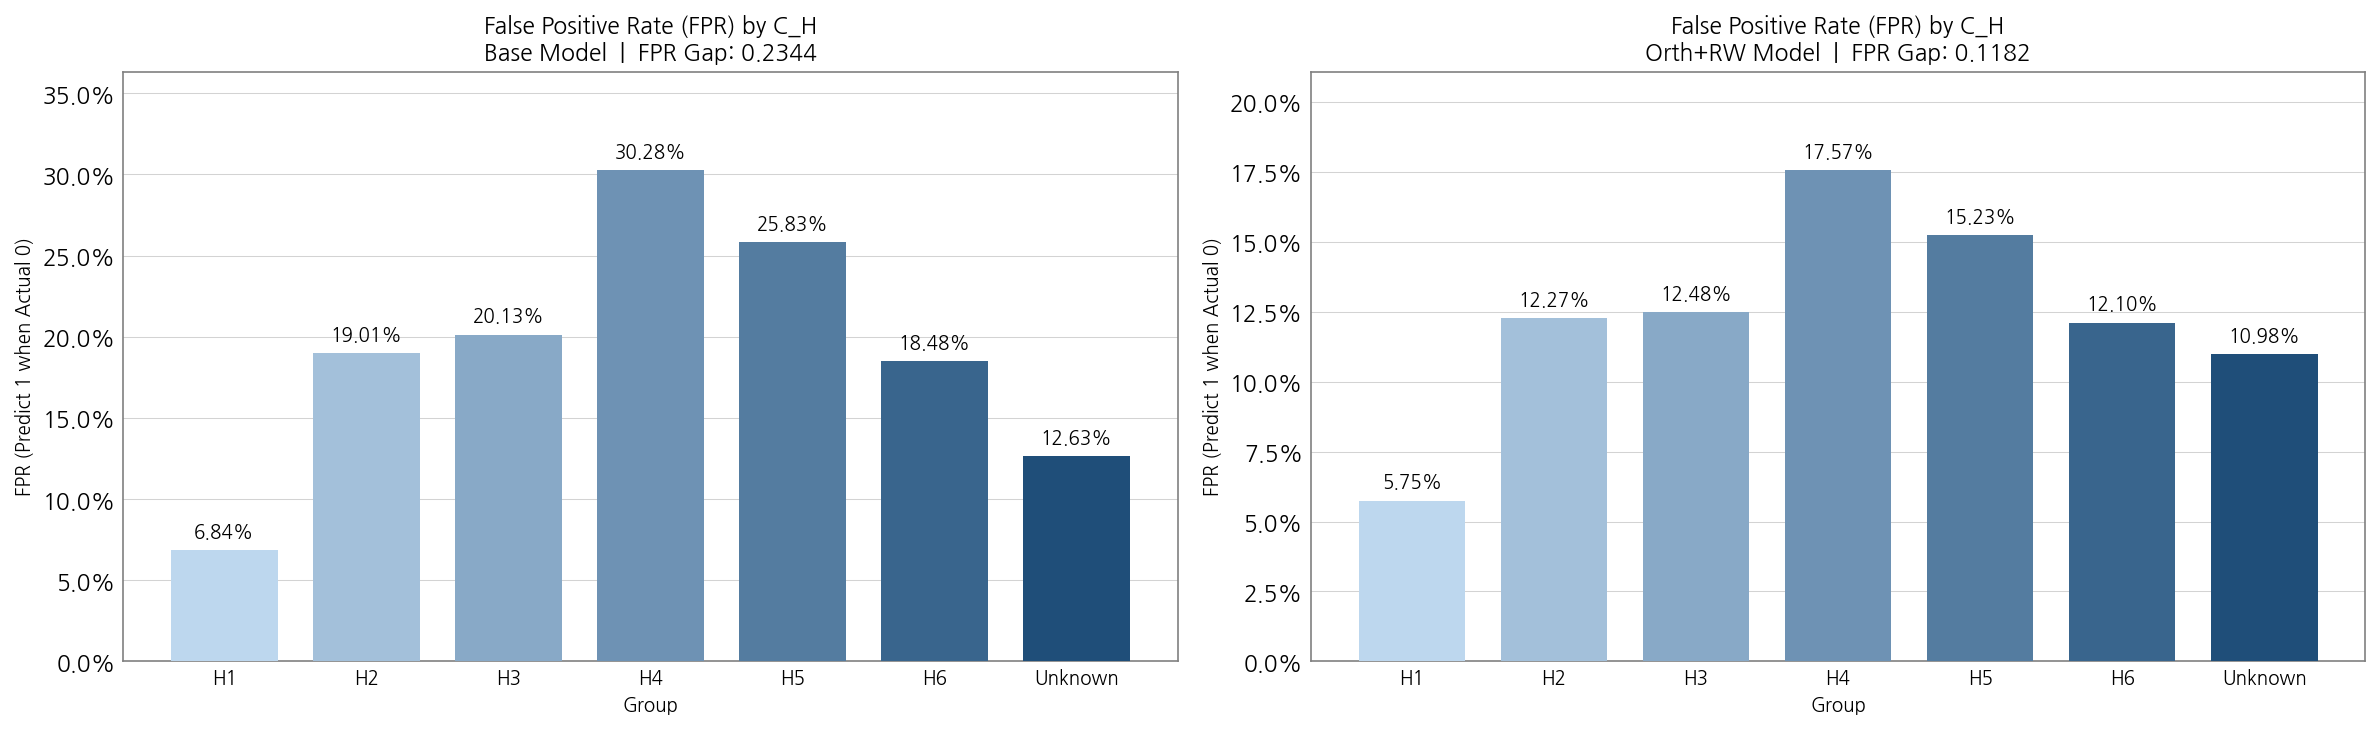

저장: fpr_comparison_c_gi.png


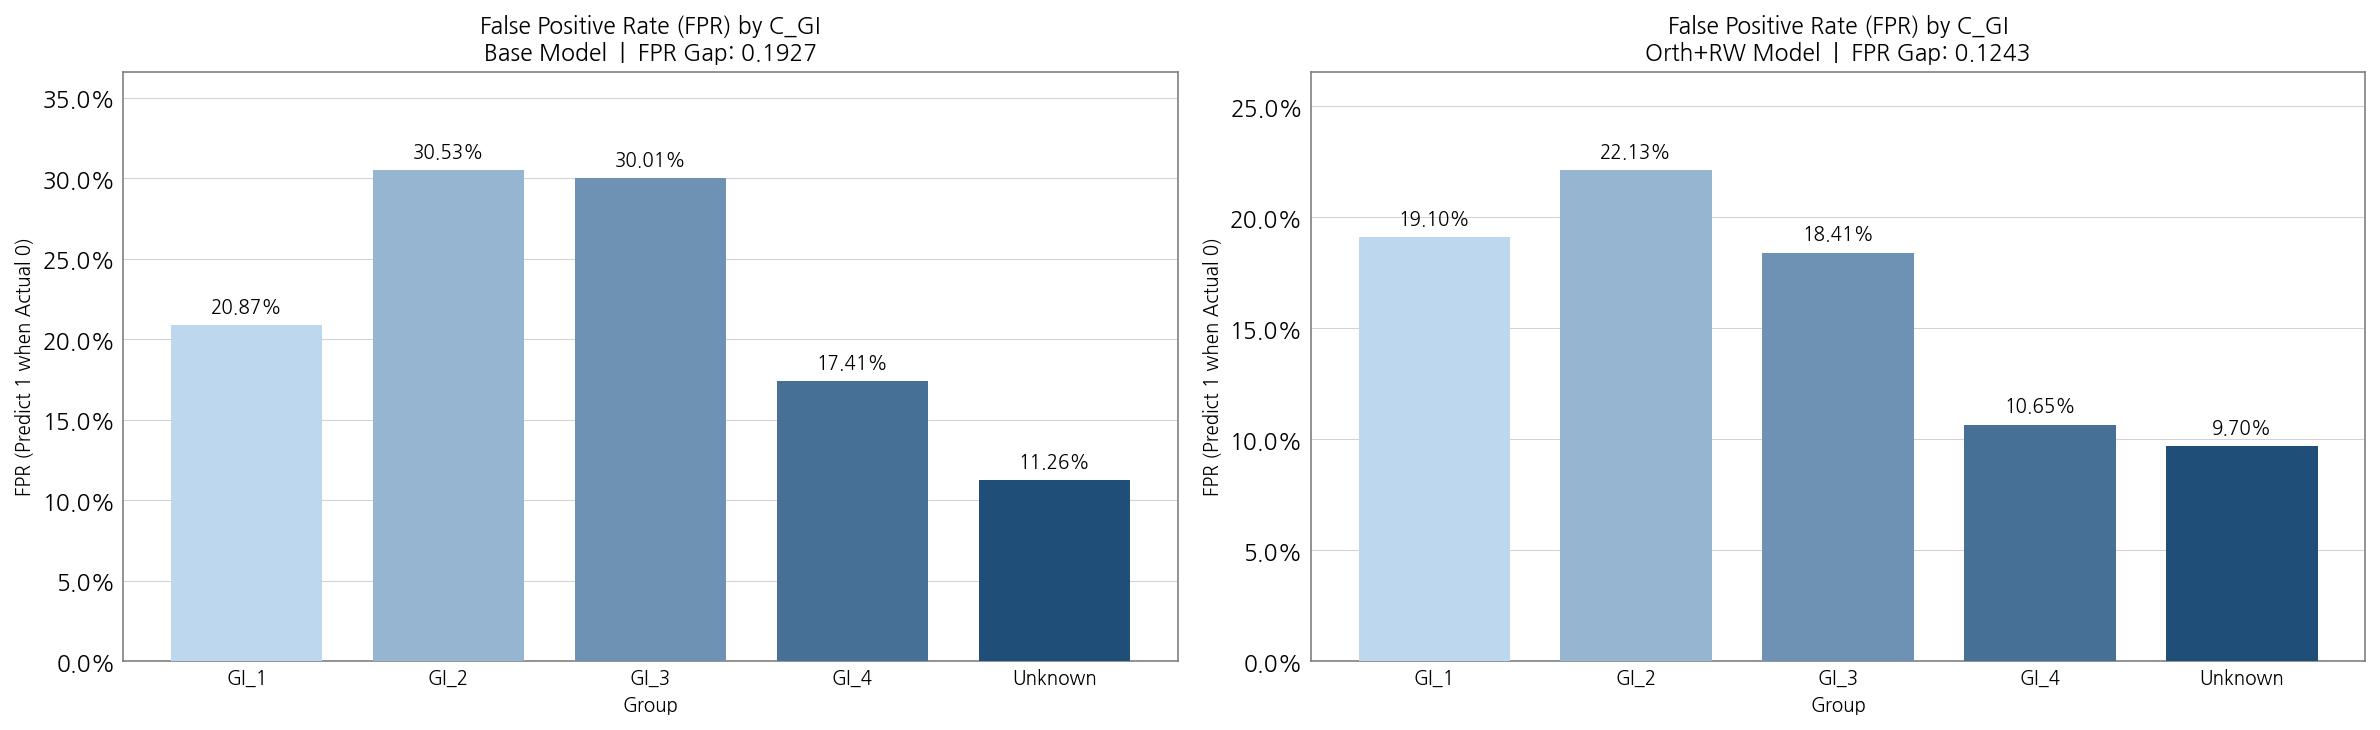

저장: fpr_comparison_c_ie_t.png


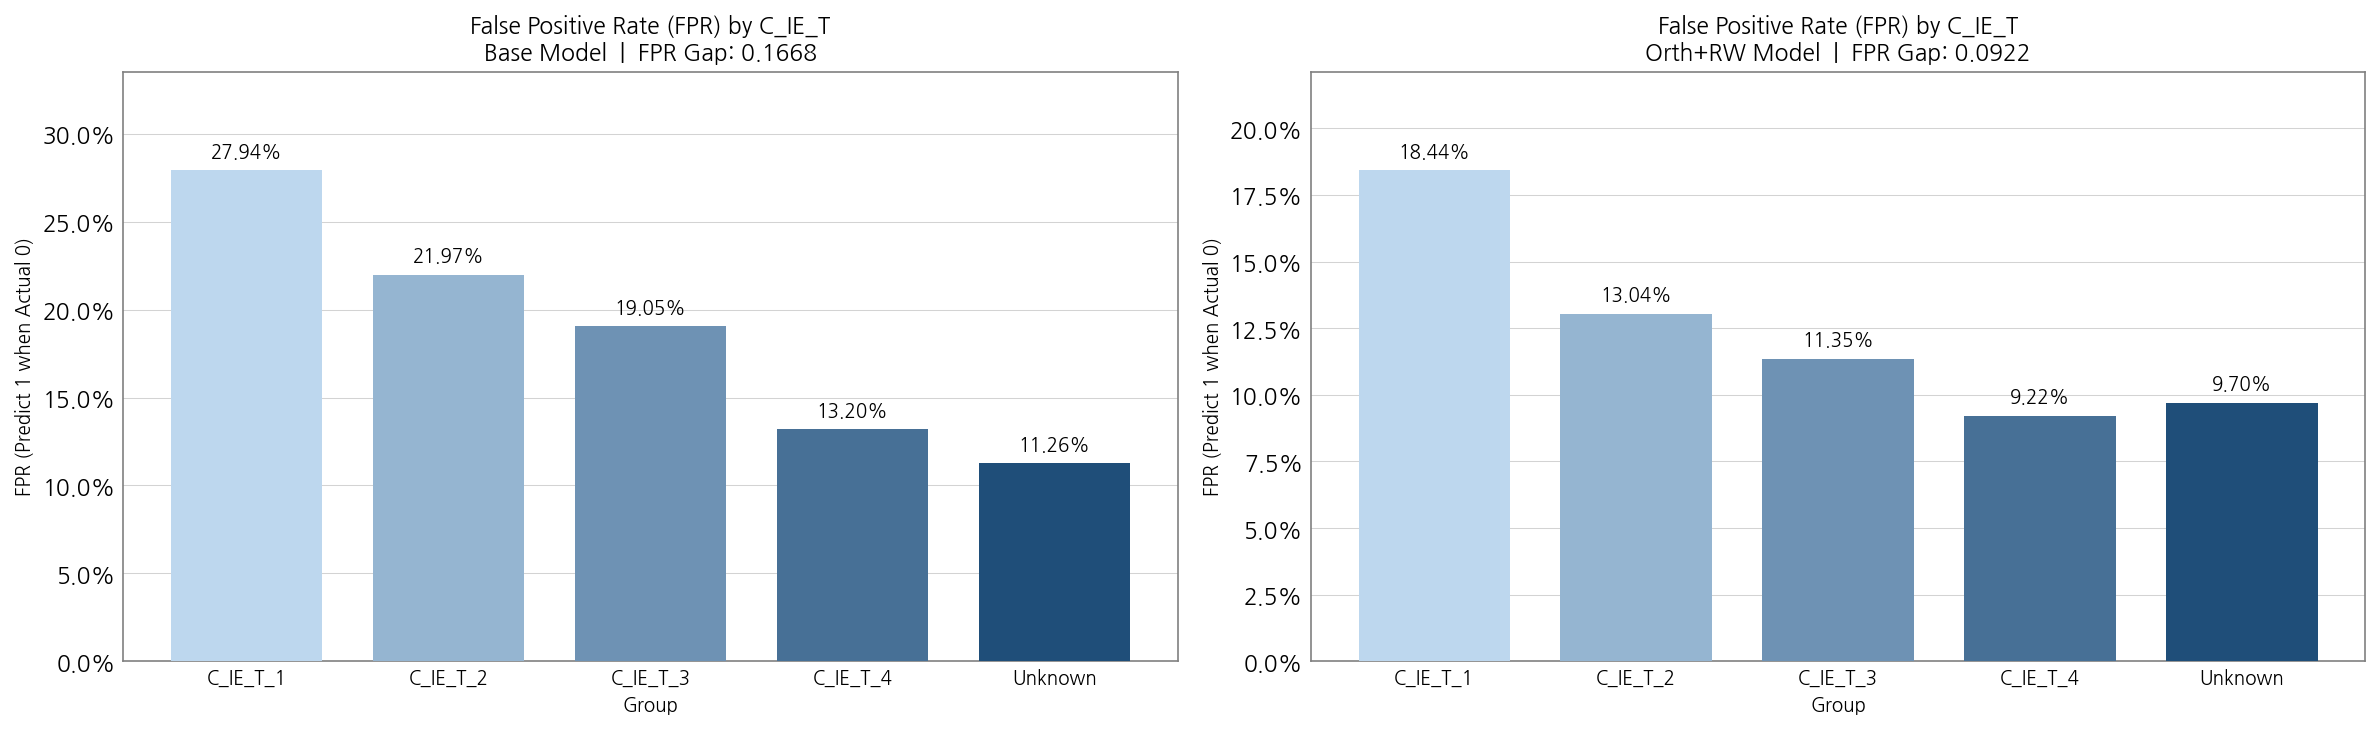


=== FPR Gap 개선 요약 ===
            Base FPR Gap  Orth+RW FPR Gap  개선율(%)
age               0.3083           0.0508    83.5
gender            0.0348           0.0000    99.9
age_gender        0.2784           0.0402    85.6
c_h               0.2344           0.1182    49.6
c_gi              0.1927           0.1243    35.5
c_ie_t            0.1668           0.0922    44.7


In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

def get_fpr_by_group(y_true, y_pred, group_col, groups):
    df = pd.DataFrame({'true': y_true, 'pred': y_pred, 'group': groups})
    results = []
    if group_col == 'age_gender':
        order = ['청년_F', '청년_M', '중년_F', '중년_M', '장년_F', '장년_M', '고령_F', '고령_M']
    elif group_col == 'age':
        order = ['10s', '20s', '30s', '40s', '50s', '60s', '70s+']
    elif group_col == 'gender':
        order = ['F', 'M']
    elif group_col == 'c_h':
        order = ['H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'Unknown']
    elif group_col == 'c_gi':
        order = ['GI_1', 'GI_2', 'GI_3', 'GI_4', 'Unknown']
    elif group_col == 'c_ie_t':
        order = ['C_IE_T_1', 'C_IE_T_2', 'C_IE_T_3', 'C_IE_T_4', 'Unknown']
    else:
        order = np.sort(df['group'].unique())

    for name in order:
        group = df[df['group'] == name]
        if len(group) < 10: continue
        tn, fp, fn, tp = confusion_matrix(group['true'], group['pred']).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        results.append({"Group": name, "FPR": fpr})
    return pd.DataFrame(results)


def plot_fpr_comparison(y_true, pred_base, pred_orw, group_col, groups, save=True):
    fpr_base = get_fpr_by_group(y_true, pred_base, group_col, groups)
    fpr_orw  = get_fpr_by_group(y_true, pred_orw,  group_col, groups)

    gap_base = fpr_base['FPR'].max() - fpr_base['FPR'].min()
    gap_orw  = fpr_orw['FPR'].max()  - fpr_orw['FPR'].min()

    label_map = {
        'age': 'Age', 'gender': 'Gender',
        'age_gender': 'Age & Gender',
        'c_h': 'C_H', 'c_gi': 'C_GI', 'c_ie_t': 'C_IE_T',
    }
    title_label = label_map.get(group_col, group_col)

    # ★ 연한 하늘색 → 진한 네이비 (이미지와 동일한 색상 범위)
    def get_colors(n):
        # 이미지 참고: 가장 연한 색 #BDD7EE ~ 가장 진한 색 #1F4E79 수준
        start = np.array([0.741, 0.843, 0.933])  # 연한 하늘색
        end   = np.array([0.122, 0.306, 0.475])  # 진한 네이비
        return [tuple(start + (end - start) * i / max(n - 1, 1)) for i in range(n)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.patch.set_facecolor('white')

    for ax, fpr_df, model_name, gap in [
        (axes[0], fpr_base, 'Base Model',    gap_base),
        (axes[1], fpr_orw,  'Orth+RW Model', gap_orw),
    ]:
        n = len(fpr_df)
        colors = get_colors(n)
        y_max  = fpr_df['FPR'].max() * 1.20

        # ★ 막대 폭 0.75 (이미지처럼 넓게)
        bars = ax.bar(
            range(n), fpr_df['FPR'],
            color=colors,
            width=0.75,
            edgecolor='none',
            zorder=3,
        )

        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.set_ylim(0, y_max)

        for bar, v in zip(bars, fpr_df['FPR']):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                v + y_max * 0.015,
                f'{v * 100:.2f}%',
                ha='center', va='bottom', fontsize=9
            )

        ax.set_xticks(range(n))
        ax.set_xticklabels(fpr_df['Group'], rotation=0, fontsize=9)
        ax.set_title(
            f'False Positive Rate (FPR) by {title_label}\n'
            f'{model_name}  |  FPR Gap: {gap:.4f}',
            fontsize=11
        )
        ax.set_ylabel('FPR (Predict 1 when Actual 0)', fontsize=9)
        ax.set_xlabel('Group', fontsize=9)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.8)
            spine.set_color('gray')

        ax.set_facecolor('white')
        ax.grid(axis='y', color='lightgray', linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)
        ax.tick_params(axis='both', length=0)

    plt.tight_layout()
    if save:
        fname = f'fpr_comparison_{group_col}.png'
        plt.savefig(fname, dpi=200, bbox_inches='tight', facecolor='white')
        print(f"저장: {fname}")
    plt.show()
    return gap_base, gap_orw


# ── 전체 민감변수 실행 ────────────────────────────────────────────
SENS_CONFIG = {
    'age'       : test_ag,
    'gender'    : test['gender'].astype(str),
    'age_gender': test_age_gender,
    'c_h'       : test['C_H_num_grp'],
    'c_gi'      : test['C_GI_grp'],
    'c_ie_t'    : test['C_IE_T_grp'],
}

summary = {}
for group_col, groups in SENS_CONFIG.items():
    gap_base, gap_orw = plot_fpr_comparison(
        y_test, pred_base, pred_orw, group_col, groups, save=True
    )
    improve = (gap_base - gap_orw) / gap_base * 100 if gap_base > 0 else 0
    summary[group_col] = {
        'Base FPR Gap'   : round(gap_base, 4),
        'Orth+RW FPR Gap': round(gap_orw,  4),
        '개선율(%)'      : round(improve,   1),
    }

summary_df = pd.DataFrame(summary).T
print("\n=== FPR Gap 개선 요약 ===")
print(summary_df.to_string())

### y_pred pickle 생성

In [22]:
import pickle
import pandas as pd
import numpy as np
import os

# ── y_pred, y_prob, y_test 준비 ──────────────────────────────────
result = {
    'y_test' : y_test.values,
    'y_prob' : prob_orw,
    'y_pred' : pred_orw,
}

# ── CSV 저장 ─────────────────────────────────────────────────────
result_df = pd.DataFrame({
    'y_test': result['y_test'],
    'y_prob': result['y_prob'],
    'y_pred': result['y_pred'],
})

csv_path = 'xgb_orth_rw_predictions.csv'
result_df.to_csv(csv_path, index=False)
print(f"CSV 저장 완료: {csv_path}")
print(f"  shape: {result_df.shape}")
print(result_df.head())

# ── Pickle 저장 ──────────────────────────────────────────────────
pkl_path = 'xgb_orth_rw_predictions.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(result, f)
print(f"\nPickle 저장 완료: {pkl_path}")

# ── 저장 확인 ────────────────────────────────────────────────────
with open(pkl_path, 'rb') as f:
    check = pickle.load(f)
print(f"\n저장 확인:")
print(f"  y_test : {check['y_test'].shape}, 분포={np.bincount(check['y_test'])}")
print(f"  y_prob : {check['y_prob'].shape}, min={check['y_prob'].min():.4f}, max={check['y_prob'].max():.4f}")
print(f"  y_pred : {check['y_pred'].shape}, 분포={np.bincount(check['y_pred'])}")

# ── Drive 저장 ───────────────────────────────────────────────────
import shutil
DRIVE_OUT = f'{BASE_PATH}/results/'
os.makedirs(DRIVE_OUT, exist_ok=True)
for fname in [csv_path, pkl_path]:
    shutil.copy(fname, DRIVE_OUT + fname)
    print(f"Drive 저장: {DRIVE_OUT + fname}")

CSV 저장 완료: xgb_orth_rw_predictions.csv
  shape: (75667, 3)
   y_test    y_prob  y_pred
0       0  0.040315       0
1       0  0.060650       0
2       0  0.223571       0
3       0  0.289036       0
4       0  0.085796       0

Pickle 저장 완료: xgb_orth_rw_predictions.pkl

저장 확인:
  y_test : (75667,), 분포=[63472 12195]
  y_prob : (75667,), min=0.0170, max=0.9896
  y_pred : (75667,), 분포=[62585 13082]
Drive 저장: /content/drive/MyDrive/Colab Notebooks/리스크 공모전/results/xgb_orth_rw_predictions.csv
Drive 저장: /content/drive/MyDrive/Colab Notebooks/리스크 공모전/results/xgb_orth_rw_predictions.pkl


In [23]:
print(y_test.index[:10])
print(type(y_test.index))

Index([152429, 152430, 152431, 152432, 152433, 152434, 152435, 152436, 152437,
       152438],
      dtype='int64')
<class 'pandas.core.indexes.base.Index'>


In [28]:
import pickle
import pandas as pd
import numpy as np
import os, shutil

# ── ID 컬럼 확인 ─────────────────────────────────────────────────
print(f"ID 샘플: {test['ID'].head(5).tolist()}")
print(f"ID 유일값 수: {test['ID'].nunique()} / 전체: {len(test)}")

# ── DataFrame 생성 ───────────────────────────────────────────────
result_df = pd.DataFrame({
    'ID'    : test['ID'].values,
    'period': test['period'].values,
    'y_test': y_test.values,
    'y_prob': prob_orw,
    'y_pred': pred_orw,
})

print(f"\n결과 DataFrame:")
print(result_df.head())
print(f"shape: {result_df.shape}")
print(f"y_pred 분포: {result_df['y_pred'].value_counts().to_dict()}")

# ── CSV 저장 ─────────────────────────────────────────────────────
csv_path = 'xgb_orth_rw_predictions.csv'
result_df.to_csv(csv_path, index=False)
print(f"\nCSV 저장 완료: {csv_path}")

# ── Pickle 저장 ──────────────────────────────────────────────────
pkl_dict = {
    'ID'    : test['ID'].values,
    'period': test['period'].values,
    'y_test': y_test.values,
    'y_prob': prob_orw,
    'y_pred': pred_orw,
}

pkl_path = 'xgb_orth_rw_predictions.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(pkl_dict, f)
print(f"Pickle 저장 완료: {pkl_path}")

# ── 저장 확인 ────────────────────────────────────────────────────
with open(pkl_path, 'rb') as f:
    check = pickle.load(f)
print(f"\n저장 확인:")
print(f"  ID     : {check['ID'].shape}")
print(f"  y_test : 분포={np.bincount(check['y_test'])}")
print(f"  y_prob : min={check['y_prob'].min():.4f}, max={check['y_prob'].max():.4f}")
print(f"  y_pred : 분포={np.bincount(check['y_pred'])}")

# ── Drive 저장 ───────────────────────────────────────────────────
DRIVE_OUT = f'{BASE_PATH}/results/'
os.makedirs(DRIVE_OUT, exist_ok=True)
for fname in [csv_path, pkl_path]:
    shutil.copy(fname, DRIVE_OUT + fname)
    print(f"Drive 저장: {DRIVE_OUT + fname}")

ID 샘플: ['1_2', '2_1', '3_3', '3_5', '3_6']
ID 유일값 수: 75667 / 전체: 75667

결과 DataFrame:
    ID  period  y_test    y_prob  y_pred
0  1_2    2019       0  0.040315       0
1  2_1    2019       0  0.060650       0
2  3_3    2019       0  0.223571       0
3  3_5    2019       0  0.289036       0
4  3_6    2019       0  0.085796       0
shape: (75667, 5)
y_pred 분포: {0: 62585, 1: 13082}

CSV 저장 완료: xgb_orth_rw_predictions.csv
Pickle 저장 완료: xgb_orth_rw_predictions.pkl

저장 확인:
  ID     : (75667,)
  y_test : 분포=[63472 12195]
  y_prob : min=0.0170, max=0.9896
  y_pred : 분포=[62585 13082]
Drive 저장: /content/drive/MyDrive/Colab Notebooks/리스크 공모전/results/xgb_orth_rw_predictions.csv
Drive 저장: /content/drive/MyDrive/Colab Notebooks/리스크 공모전/results/xgb_orth_rw_predictions.pkl


## 17. JSON 보고서

In [ ]:
# ════════════════════════════════════════════════════════════════
# XGB + Orth + RW JSON 보고서 생성 (변수별)
# ════════════════════════════════════════════════════════════════
!pip install shap fairlearn -q
import shap, json as jl, os, warnings
from fairlearn.metrics import (
    MetricFrame, selection_rate, true_positive_rate, false_positive_rate
)

# ── false_negative_rate ──────────────────────────────────────────
def false_negative_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return fn / (fn + tp) if (fn + tp) > 0 else 0.0

# ── fairness_report (원본 형식 그대로) ───────────────────────────
def fairness_report(y_true, y_pred, y_prob, sensitive_features, threshold_info):
    mf = MetricFrame(
        metrics={
            "selection_rate":      selection_rate,
            "true_positive_rate":  true_positive_rate,
            "false_positive_rate": false_positive_rate,
            "false_negative_rate": false_negative_rate,
        },
        y_true=y_true, y_pred=y_pred,
        sensitive_features=sensitive_features,
    )
    return {
        "model_performance": {
            "f1_score":  float(f1_score(y_true, y_pred, zero_division=0)),
            "pr_auc":    float(average_precision_score(y_true, y_prob)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        },
        "threshold_strategy": threshold_info,
        "fairness_metrics_by_group":  mf.by_group.to_dict(),
        "fairness_max_disparity":     mf.difference(method='between_groups').to_dict(),
    }

# ── shap_summary (샘플링 적용) ────────────────────────────────────
def shap_summary(model, x_data, n_sample=5000, random_state=42):
    """
    x_data: DataFrame (feature_names 컬럼 포함)
    샘플링: 전체 대신 n_sample개만 사용해 속도 최적화
    """
    if len(x_data) > n_sample:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(len(x_data), n_sample, replace=False)
        x_sample = x_data.iloc[idx].reset_index(drop=True)
    else:
        x_sample = x_data.copy()

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        explainer   = shap.TreeExplainer(model,
                                         feature_perturbation='interventional',
                                         model_output='raw')
        shap_values = explainer.shap_values(x_sample, check_additivity=False)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    importance = np.abs(shap_values).mean(0)
    correlations = []
    for i, col in enumerate(x_sample.columns):
        if x_sample[col].dtype.name == 'category':
            fdata = x_sample[col].cat.codes.astype(float)
        elif pd.api.types.is_numeric_dtype(x_sample[col]):
            fdata = x_sample[col].astype(float)
        else:
            correlations.append(np.nan); continue
        corr = (float(np.corrcoef(fdata, shap_values[:, i])[0, 1])
                if len(np.unique(fdata)) >= 2 and len(np.unique(shap_values[:, i])) >= 2
                else np.nan)
        correlations.append(corr)

    shap_df = pd.DataFrame({
        'feature': x_sample.columns, 'importance': importance, 'correlation': correlations
    }).sort_values('importance', ascending=False)

    shap_dict = {}
    for _, row in shap_df.head(10).iterrows():
        c = row['correlation']
        if pd.isna(c):
            dir_info = "N/A (Correlation undefined)"
        else:
            dir_info = f"{'Positive' if c > 0 else 'Negative'} (Correlation: {c:.2f})"
        shap_dict[row['feature']] = {
            "importance": round(float(row['importance']), 4),
            "influence":  dir_info,
        }
    return shap_dict

# ── create_final_report (방법론 2개: Orth / Orth+RW) ─────────────
def create_final_report(model_objective, model_type, var_name,
                        before_tuning_dict,
                        orth_dict, orth_rw_dict,
                        shap_before=None, shap_after=None):
    return {
        "project_name": "Fairness-Aware Health Insurance Churn Prediction",
        "model_objective": model_objective,
        "model_type":      model_type,
        "primary_sensitive_feature": var_name,
        "all_sensitive_features": ["gender","age","age_gender","c_h","c_gi","c_ie_t"],
        "model_evaluation": {
            var_name: {
                "before_tuning": {
                    "tuning":   "None",
                    "results":  before_tuning_dict,
                },
                "after_tuning_comparison": [
                    {
                        "index":         1,
                        "tuning_method": "Pre-processing: Orthogonalization",
                        "description":   f"R²>{best_r2['R2_thr']} 기저(age 연속+²+더미+gender+교호작용) 직교화 후 재학습, Base threshold 고정",
                        "results":       orth_dict,
                    },
                    {
                        "index":         2,
                        "tuning_method": "Pre-processing: Orthogonalization + Reweighting",
                        "description":   (f"R²>{best_r2['R2_thr']} 직교화 + age_group×gender "
                                          "역빈도 가중치(N/n_cells×cell_count) 동시 적용, Base threshold 고정"),
                        "results":       orth_rw_dict,
                    },
                ],
            }
        },
        "explainability_analysis": {
            "baseline_model_shap":  shap_before,
            "best_model_shap":      shap_after,
            "best_model_description": "Orthogonalization + Reweighting",
            "methodology": ("SHAP (SHapley Additive exPlanations) summary values "
                            "— mean absolute importance and feature influence direction "
                            f"(sampled {5000} / {len(x_test_orth_arr)} test samples)"),
        },
    }

# ── SHAP 계산 (샘플링) ────────────────────────────────────────────
# base_model: 원본 x_test (category dtype)
x_test_prepared_df = test[feature_names].copy()
for col in cat_cols:
    x_test_prepared_df[col] = x_test_prepared_df[col].astype(str).astype('category')

# Orth+RW 모델: 직교화된 numpy → DataFrame 변환
x_test_orth_df = pd.DataFrame(x_test_orth_arr, columns=feature_names)

print("Base SHAP 계산 중 (5,000개 샘플링)...")
shap_base = shap_summary(base_model, x_test_prepared_df, n_sample=5000)
print("  완료")

print("Orth+RW SHAP 계산 중 (5,000개 샘플링)...")
shap_orw  = shap_summary(model_orw, x_test_orth_df, n_sample=5000)
print("  완료")

# ── threshold 정보 ────────────────────────────────────────────────
thr_base = {"strategy": "Base (No Fairness Tuning)", "threshold": float(threshold)}
thr_orth = {
    "strategy":        "Pre-processing (Orthogonalization) + Fixed Threshold",
    "description":     f"R²>{best_r2['R2_thr']} 직교화 후 재학습, Base threshold 고정",
    "threshold":       float(threshold),
    "threshold_basis": "Base Model val(2018) F1 최적화 (공통 고정)",
}
thr_orw = {
    "strategy":        "Pre-processing (Orthogonalization + Reweighting) + Fixed Threshold",
    "description":     f"R²>{best_r2['R2_thr']} 직교화 + age_group×gender 가중치, Base threshold 고정",
    "threshold":       float(threshold),
    "threshold_basis": "Base Model val(2018) F1 최적화 (공통 고정)",
}

# ── 민감변수 레이블 매핑 ──────────────────────────────────────────
SENS_LABEL_MAP = {
    'age_group':'age', 'gender':'gender', 'age_gender':'age_gender',
    'c_h':'C_H', 'c_gi':'C_GI', 'c_ie_t':'C_IE_T',
}

# ── 변수별 JSON 생성 ──────────────────────────────────────────────
os.makedirs('reports', exist_ok=True)

for sens_key, sens_grp in sensitive_test.items():
    var_label = SENS_LABEL_MAP[sens_key]
    print(f"\n[{var_label}] JSON 생성 중...")

    before_dict = fairness_report(y_test, pred_base, prob_base, sens_grp, thr_base)
    orth_dict   = fairness_report(y_test, pred_orth, prob_orth, sens_grp, thr_orth)
    orw_dict    = fairness_report(y_test, pred_orw,  prob_orw,  sens_grp, thr_orw)

    report = create_final_report(
        model_objective    = "Churn Prediction",
        model_type         = "XGBoost (Optuna)",
        var_name           = var_label,
        before_tuning_dict = before_dict,
        orth_dict          = orth_dict,
        orth_rw_dict       = orw_dict,
        shap_before        = shap_base,
        shap_after         = shap_orw,
    )

    fname = f'reports/{var_label}_xgb.json'
    with open(fname, 'w', encoding='utf-8') as f:
        jl.dump(report, f, ensure_ascii=False, indent=2, default=str)
    print(f"  저장: {fname}")

print("\n전체 JSON 생성 완료")
print(f"생성 파일: {[f'reports/{SENS_LABEL_MAP[k]}_xgb.json' for k in sensitive_test]}")

# ── Drive 저장 ────────────────────────────────────────────────────
import shutil
DRIVE_OUT = f'{BASE_PATH}/reports/'
os.makedirs(DRIVE_OUT, exist_ok=True)
for sens_key in sensitive_test:
    fname = f'reports/{SENS_LABEL_MAP[sens_key]}_xgb.json'
    shutil.copy(fname, DRIVE_OUT + os.path.basename(fname))
    print(f"Drive 저장: {DRIVE_OUT + os.path.basename(fname)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 23.3 MB/s eta 0:00:00
Base SHAP 계산 중 (5,000개 샘플링)...
  완료
Orth+RW SHAP 계산 중 (5,000개 샘플링)...
  완료

[age] JSON 생성 중...
  저장: reports/age_xgb.json

[gender] JSON 생성 중...
  저장: reports/gender_xgb.json

[age_gender] JSON 생성 중...
  저장: reports/age_gender_xgb.json

[C_H] JSON 생성 중...
  저장: reports/C_H_xgb.json

[C_GI] JSON 생성 중...
  저장: reports/C_GI_xgb.json

[C_IE_T] JSON 생성 중...
  저장: reports/C_IE_T_xgb.json

전체 JSON 생성 완료
생성 파일: ['reports/age_xgb.json', 'reports/gender_xgb.json', 'reports/age_gender_xgb.json', 'reports/C_H_xgb.json', 'reports/C_GI_xgb.json', 'reports/C_IE_T_xgb.json']
Drive 저장: /content/drive/MyDrive/Colab Notebooks/리스크 공모전/reports/age_xgb.json
Drive 저장: /content/drive/MyDrive/Colab Notebooks/리스크 공모전/reports/gender_xgb.json
Drive 저장: /content/drive/MyDrive/Col

## 18. 결과 저장

In [ ]:
import shutil, os, glob
DRIVE_OUT = f'{BASE_PATH}/results/'; os.makedirs(DRIVE_OUT, exist_ok=True)
for f in glob.glob('fpr_*.png')+glob.glob('*.json')+['pareto_search.png','shap_comparison.png','fpr_gap_analysis.png']:
    if os.path.exists(f): shutil.copy(f, DRIVE_OUT+f); print(f"저장: {f}")
print("완료")


---
## GLM 모델 공정성 개선

### GLM-1. 모델 로드 및 Pipeline 재구성

In [ ]:
import pickle
from scipy.special import expit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.utils.class_weight import compute_sample_weight

GLM_PKL = f'{BASE_PATH}/churn_model_glm_final.pkl'

with open(GLM_PKL, 'rb') as f:
    glm_pkg = pickle.load(f)

glm_thr     = float(glm_pkg['threshold'])
glm_xcols   = glm_pkg['features']['x_cols']
glm_numcols = glm_pkg['features']['num_cols']
glm_catcols = glm_pkg['features']['cat_cols']
old_lr      = glm_pkg['model'].named_steps['model']

print(f"GLM threshold: {glm_thr}")
print(f"num_cols ({len(glm_numcols)}개): {glm_numcols}")
print(f"cat_cols ({len(glm_catcols)}개): {glm_catcols}")

def make_glm_pipeline(use_class_weight=False):
    """
    use_class_weight=False: Base / Orth 단독 (class_weight 없음, 원본과 동일)
    use_class_weight=True : Orth+RW (class_weight='balanced'로 클래스 불균형 보정)
    """
    pre = ColumnTransformer(transformers=[
        ('num', StandardScaler(),            glm_numcols),
        ('cat', OneHotEncoder(drop='first'), glm_catcols),
    ])
    lr = LogisticRegression(
        C=old_lr.C, l1_ratio=old_lr.l1_ratio, penalty=old_lr.penalty,
        solver=old_lr.solver, max_iter=old_lr.max_iter,
        random_state=old_lr.random_state, n_jobs=old_lr.n_jobs,
        fit_intercept=old_lr.fit_intercept,
        class_weight='balanced' if use_class_weight else None,
    )
    return Pipeline(steps=[('preprocessor', pre), ('model', lr)])

print("make_glm_pipeline 정의 완료")


### GLM-2. 데이터 준비

In [ ]:
# GLM용 DataFrame (원본 train/test에서 복사 - 원본 수정 없음)
x_train_glm = train[glm_xcols].copy()
x_test_glm  = test[glm_xcols].copy()
for col in glm_catcols:
    x_train_glm[col] = x_train_glm[col].astype(str)
    x_test_glm[col]  = x_test_glm[col].astype(str)

# num_cols만 float 변환 (R² 측정용)
x_train_glm_num = x_train_glm[glm_numcols].astype(float)
x_test_glm_num  = x_test_glm[glm_numcols].astype(float)

print(f"x_train_glm: {x_train_glm.shape}")
print(f"x_test_glm : {x_test_glm.shape}")


### GLM-3. 민감변수 그룹 정의
GLM 전용 컬럼(`_glm_grp`)과 dict(`sensitive_test_glm`)를 별도 사용


In [ ]:
# GLM 민감변수: XGBoost sens_config와 동일한 구간/매핑 기준 사용
for key, cfg in sens_config.items():
    col = cfg['col']
    for df in [train, test]:
        if 'bins' in cfg:
            df[f'{col}_glm_grp'] = pd.cut(
                df[col], bins=cfg['bins'], labels=cfg['labels'],
                right=True, include_lowest=True
            ).astype(str)
        else:
            df[f'{col}_glm_grp'] = df[col].map(cfg['map']).fillna('Unknown')

glm_test_age_gender = (
    pd.cut(test['age'], bins=AG_BINS, labels=AG_LABELS).astype(str)
    + '_' + test['gender'].astype(str)
)

sensitive_test_glm = {
    'age_group':  test_ag,
    'gender':     test['gender'].astype(str),
    'age_gender': glm_test_age_gender,
    'c_h':        test['C_H_num_glm_grp'],
    'c_gi':       test['C_GI_glm_grp'],
    'c_ie_t':     test['C_IE_T_glm_grp'],
}

for k, v in sensitive_test_glm.items():
    print(f"  {k:12s}: {sorted(v.unique())}")

print(f"\nXGBoost C_GI_grp:     {sorted(test['C_GI_grp'].unique())}")
print(f"GLM     C_GI_glm_grp: {sorted(test['C_GI_glm_grp'].unique())}")
print("→ 동일 기준 확인")

### GLM-4. Base GLM 성능 확인

In [ ]:
# 원본 pkl 모델로 예측 (decision_function으로 multi_class 오류 우회)
glm_orig = glm_pkg['model']
try:
    prob_glm_base = glm_orig.predict_proba(x_test_glm)[:, 1]
except AttributeError:
    prob_glm_base = expit(glm_orig.decision_function(x_test_glm))

pred_glm_base = (prob_glm_base >= glm_thr).astype(int)

print("=== GLM Base Model ===")
for k, v in get_metrics(y_test, prob_glm_base, pred_glm_base).items():
    print(f"  {k}: {v}")
print(f"  Avg FPR Gap: {avg_fpr_gap(y_test, pred_glm_base, sensitive_test_glm):.4f}")


### GLM-5. Feature별 R² 측정

In [ ]:
# basis_tr, basis_te는 XGBoost에서 이미 계산된 값 재사용
r2_glm = {}
for col in glm_numcols:
    if col in ('age', 'gender'): continue
    x_tr = x_train_glm_num[col].values.astype(float)
    if np.isnan(x_tr).any() or np.std(x_tr) == 0:
        r2_glm[col] = 0.0; continue
    pred_r2 = LinearRegression().fit(basis_tr, x_tr).predict(basis_tr)
    ss_res = np.sum((x_tr - pred_r2)**2)
    ss_tot = np.sum((x_tr - x_tr.mean())**2)
    r2_glm[col] = round(max(0.0, 1 - ss_res/ss_tot), 4)

r2_glm_series = pd.Series(r2_glm).sort_values(ascending=False)
print("GLM Feature별 R²:")
print(r2_glm_series.to_string())


### GLM-6. R² Threshold Pareto 탐색

In [ ]:
R2_GRID_GLM    = [0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3]
base_prauc_glm = average_precision_score(y_test, prob_glm_base)
PRAUC_DROP_GLM = base_prauc_glm * 0.02

print(f"GLM Base PR-AUC: {base_prauc_glm:.4f}, 허용 하락: {PRAUC_DROP_GLM:.4f} (2%)")

pareto_glm = []
for r2_thr in R2_GRID_GLM:
    cols = r2_glm_series[r2_glm_series > r2_thr].index.tolist()

    x_tr_o, x_te_o = x_train_glm.copy(), x_test_glm.copy()
    for col in cols:
        reg = Ridge(alpha=1.0).fit(basis_tr, x_train_glm_num[col].values.astype(float))
        x_tr_o[col] = x_train_glm_num[col].values.astype(float) - reg.predict(basis_tr)
        x_te_o[col] = x_test_glm_num[col].values.astype(float)  - reg.predict(basis_te)

    m_o = make_glm_pipeline()
    m_o.fit(x_tr_o, y_train)
    prob_o = m_o.predict_proba(x_te_o)[:, 1]
    pred_o = (prob_o >= glm_thr).astype(int)

    prauc = average_precision_score(y_test, prob_o)
    gap   = avg_fpr_gap(y_test, pred_o, sensitive_test_glm)
    ok    = (base_prauc_glm - prauc) <= PRAUC_DROP_GLM

    pareto_glm.append({'R2_thr':r2_thr, 'n_cols':len(cols),
        'PR-AUC':round(prauc,4), 'Avg FPR Gap':gap,
        'drop':round(base_prauc_glm-prauc,4), 'ok':ok,
        'prob':prob_o, 'pred':pred_o})
    print(f"  R²>{r2_thr:.2f} | {len(cols):2d}개 | "
          f"PR-AUC={prauc:.4f}({base_prauc_glm-prauc:+.4f}) | "
          f"Gap={gap:.4f} {'✅' if ok else '❌'}")

pareto_glm_df = pd.DataFrame([
    {k:v for k,v in r.items() if k not in ('prob','pred')}
    for r in pareto_glm
]).set_index('R2_thr')
display(pareto_glm_df)

# 최적 R² 선택
feas_glm    = [r for r in pareto_glm if r['ok']]
best_r2_glm = min(feas_glm, key=lambda r: r['Avg FPR Gap']) if feas_glm else None
if best_r2_glm:
    print(f"\n★ GLM 최적: R²>{best_r2_glm['R2_thr']}, "
          f"{best_r2_glm['n_cols']}개, "
          f"PR-AUC={best_r2_glm['PR-AUC']:.4f}, "
          f"Gap={best_r2_glm['Avg FPR Gap']:.4f}")
else:
    print("❌ feasible 없음. PRAUC_DROP_GLM을 높여보세요.")


### GLM-7. 직교화 수행 + Reweighting + 모델 학습

In [ ]:
# ── 직교화 ───────────────────────────────────────────────────────────
cols_orth_glm = r2_glm_series[r2_glm_series > best_r2_glm['R2_thr']].index.tolist()
print(f"GLM 직교화 대상: {cols_orth_glm}")

x_train_glm_orth, x_test_glm_orth = x_train_glm.copy(), x_test_glm.copy()
for col in cols_orth_glm:
    reg = Ridge(alpha=1.0).fit(basis_tr, x_train_glm_num[col].values.astype(float))
    x_train_glm_orth[col] = x_train_glm_num[col].values.astype(float) - reg.predict(basis_tr)
    x_test_glm_orth[col]  = x_test_glm_num[col].values.astype(float)  - reg.predict(basis_te)

# ── Orth 단독 ────────────────────────────────────────────────────────
model_glm_orth = make_glm_pipeline(use_class_weight=False)
model_glm_orth.fit(x_train_glm_orth, y_train)
prob_glm_orth = model_glm_orth.predict_proba(x_test_glm_orth)[:, 1]
pred_glm_orth = (prob_glm_orth >= glm_thr).astype(int)

# ── Orth + RW ────────────────────────────────────────────────────────
# class_weight='balanced'로 클래스 불균형 보정 후
# sample_weights에서 클래스 불균형 효과를 제거 → 공정성 보정만 남김
class_w = compute_sample_weight('balanced', y_train)
fairness_w = sample_weights / class_w
fairness_w = fairness_w / fairness_w.mean()

print(f"공정성 전용 가중치: min={fairness_w.min():.3f}, "
      f"max={fairness_w.max():.3f}, ratio={fairness_w.max()/fairness_w.min():.1f}")

model_glm_orw = make_glm_pipeline(use_class_weight=True)
model_glm_orw.fit(x_train_glm_orth, y_train,
                  model__sample_weight=fairness_w)
prob_glm_orw = model_glm_orw.predict_proba(x_test_glm_orth)[:, 1]
pred_glm_orw = (prob_glm_orw >= glm_thr).astype(int)

for nm_m, pd_ in [('Orth', pred_glm_orth), ('Orth+RW', pred_glm_orw)]:
    print(f"GLM {nm_m:8s}: 양성 {pd_.sum():,}/{len(pd_):,} ({pd_.mean():.1%}), "
          f"FPR={calc_fpr(y_test, pd_):.4f}")


### GLM-8. 성능 비교

In [ ]:
glm_models_eval = {
    'Base'   : {'prob': prob_glm_base, 'pred': pred_glm_base},
    'Orth'   : {'prob': prob_glm_orth, 'pred': pred_glm_orth},
    'Orth+RW': {'prob': prob_glm_orw,  'pred': pred_glm_orw},
}

glm_perf_rows = [{'Model': name,
                  **get_metrics(y_test, m['prob'], m['pred']),
                  'Avg FPR Gap': avg_fpr_gap(y_test, m['pred'], sensitive_test_glm)}
                 for name, m in glm_models_eval.items()]
glm_perf_df = pd.DataFrame(glm_perf_rows).set_index('Model')

display(glm_perf_df.style.apply(hl).apply(hl_b, axis=None)
    .format('{:.4f}').set_caption("GLM 성능·공정성 비교 | 🟡 Base | 🟢 최우수"))

glm_delta = glm_perf_df.drop('Base').apply(
    lambda r: r - glm_perf_df.loc['Base'], axis=1)
display(glm_delta.style.apply(hl_d)
    .format('{:+.4f}').set_caption("GLM Base 대비 변화량 | 🟢 개선 | 🔴 악화"))


### GLM-9. 민감변수별 FPR Distribution 그래프

In [ ]:
glm_methods_cmp = {'Orth': pred_glm_orth, 'Orth+RW': pred_glm_orw}
glm_m_colors    = {'Orth': '#1f77b4', 'Orth+RW': '#9467bd'}

for sn, grps in sensitive_test_glm.items():
    for mn_g, mpred in glm_methods_cmp.items():
        fb = group_fpr_dict(y_test, pred_glm_base, grps)
        fm = group_fpr_dict(y_test, mpred, grps)
        labs = sorted(fb.keys())
        if not labs: continue
        bv   = [fb.get(g, 0) for g in labs]
        mv   = [fm.get(g, 0) for g in labs]
        ymax = min(1.05, max(bv + mv) * 1.15)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
        fig.suptitle(f'GLM - FPR Distribution by {sn}',
                     fontsize=14, fontweight='bold')

        for ax, vals, gap_v, title, color in [
            (axes[0], bv, fpr_gap(fb), 'Base Model',   '#5b9bd5'),
            (axes[1], mv, fpr_gap(fm), f'{mn_g} Model', glm_m_colors[mn_g]),
        ]:
            ax.bar(range(len(labs)), vals, color=color,
                   edgecolor='k', linewidth=0.3, alpha=0.85)
            ax.axhline(np.mean(vals), color='red', ls='--', lw=1,
                       label=f'평균: {np.mean(vals):.3f}')
            for i, v in enumerate(vals):
                ax.text(i, v + ymax*0.02, f'{v:.3f}', ha='center', fontsize=9)
            ax.set_xticks(range(len(labs)))
            ax.set_xticklabels(labs, rotation=30, ha='right', fontsize=9)
            ax.set_ylabel('FPR'); ax.set_title(f'{title}\nFPR Gap: {gap_v:.4f}')
            ax.set_ylim(0, ymax); ax.legend(fontsize=9)
            ax.grid(axis='y', alpha=0.2); ax.set_xlabel('Category')

        plt.tight_layout()
        plt.savefig(f'glm_fpr_{sn}_{mn_g}.png', dpi=200, bbox_inches='tight')
        plt.show()


### GLM-10. FPR Gap 히트맵

In [ ]:
glm_gap_matrix = {
    mn_g: {s: fpr_gap(group_fpr_dict(y_test, m['pred'], g))
           for s, g in sensitive_test_glm.items()}
    for mn_g, m in glm_models_eval.items()
}
glm_gap_df = pd.DataFrame(glm_gap_matrix)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

ax = axes[0]; d = glm_gap_df.values.T.astype(float)
im = ax.imshow(d, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=max(0.01, d.max()))
ax.set_xticks(range(len(glm_gap_df.index)))
ax.set_xticklabels(glm_gap_df.index, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(glm_gap_df.columns)))
ax.set_yticklabels(glm_gap_df.columns, fontsize=10)
ax.set_title('(a) GLM FPR Gap Heatmap')
plt.colorbar(im, ax=ax, label='FPR Gap', shrink=0.8)
for i in range(len(glm_gap_df.columns)):
    for j in range(len(glm_gap_df.index)):
        ax.text(j, i, f'{d[i,j]:.3f}', ha='center', va='center',
                fontsize=9, color='black')

ax  = axes[1]
dg  = glm_gap_df.drop(columns='Base').apply(lambda c: glm_gap_df['Base'] - c)
xg  = np.arange(len(dg.index)); nm_g = len(dg.columns); wg = 0.8 / nm_g
for i, col in enumerate(dg.columns):
    cs = ['#2ca02c' if v > 0 else '#d62728' for v in dg[col]]
    ax.bar(xg + i*wg, dg[col], wg, label=col, color=cs,
           alpha=0.85, edgecolor='k', linewidth=0.3)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(xg + wg*(nm_g-1)/2)
ax.set_xticklabels(dg.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('$\Delta$ FPR Gap (↑ = improved)')
ax.set_title('(b) GLM FPR Gap Improvement over Base')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('glm_fpr_gap_analysis.png', dpi=200, bbox_inches='tight')
plt.show()


In [ ]:
# ── 변수별 FPR Gap, Avg FPR, Max FPR 계산 함수 ───────────────────
def get_var_fpr_stats(y_true, y_pred, sens_dict):
    """변수별 FPR Gap / Avg FPR / Max FPR 반환"""
    stats = {}
    for var, groups in sens_dict.items():
        grp_fprs = []
        for g in sorted(groups.dropna().unique()):
            mask = (groups == g).values
            if mask.sum() < 10: continue
            yt, yp = np.array(y_true)[mask], np.array(y_pred)[mask]
            if len(np.unique(yt)) < 2: continue
            grp_fprs.append(calc_fpr(yt, yp))
        if grp_fprs:
            stats[var] = {
                'gap': max(grp_fprs) - min(grp_fprs),
                'avg': np.mean(grp_fprs),
                'max': max(grp_fprs),
            }
        else:
            stats[var] = {'gap': 0.0, 'avg': 0.0, 'max': 0.0}
    return stats

# ── 가중치 계산 ───────────────────────────────────────────────────
def calc_var_weights(y_true, y_pred, sens_dict):
    n_groups = {}
    for var, groups in sens_dict.items():
        cnt = sum(
            1 for g in sorted(groups.dropna().unique())
            if (groups == g).sum() >= 10
            and len(np.unique(np.array(y_true)[(groups == g).values])) >= 2
        )
        n_groups[var] = cnt
    total = sum(n_groups.values())
    return {var: n / total for var, n in n_groups.items()}, n_groups

# ── 가중 개선율 계산 ──────────────────────────────────────────────
def calc_weighted_improvement(base_stats, cur_stats, var_weights):
    """
    변수별 개선율 먼저 계산 → 가중치 곱해서 합산
    예: age FPR Gap 개선율 × (7/34) + gender FPR Gap 개선율 × (2/34) + ...
    """
    w_gap_improve = 0.0
    w_avg_change  = 0.0
    w_max_change  = 0.0

    for var, w in var_weights.items():
        b = base_stats.get(var, {})
        c = cur_stats.get(var, {})

        b_gap = b.get('gap', 0.0)
        b_avg = b.get('avg', 0.0)
        b_max = b.get('max', 0.0)
        c_gap = c.get('gap', 0.0)
        c_avg = c.get('avg', 0.0)
        c_max = c.get('max', 0.0)

        # 변수별 개선율
        var_gap_improve = (b_gap - c_gap) / b_gap if b_gap > 0 else 0.0
        var_avg_change  = (b_avg - c_avg) / b_avg if b_avg > 0 else 0.0
        var_max_change  = (b_max - c_max) / b_max if b_max > 0 else 0.0

        # 가중 합산
        w_gap_improve += w * var_gap_improve
        w_avg_change  += w * var_avg_change
        w_max_change  += w * var_max_change

    return w_gap_improve, w_avg_change, w_max_change

# ── 기준 지표 계산 ────────────────────────────────────────────────
xgb_weights, xgb_n = calc_var_weights(y_test, pred_base, sensitive_test)
glm_weights, glm_n = calc_var_weights(y_test, pred_glm_base, sensitive_test_glm)

base_xgb_stats = get_var_fpr_stats(y_test, pred_base, sensitive_test)
base_glm_stats = get_var_fpr_stats(y_test, pred_glm_base, sensitive_test_glm)

base_xgb_f1 = f1_score(y_test, pred_base, zero_division=0)
base_glm_f1 = f1_score(y_test, pred_glm_base, zero_division=0)

print("=== XGBoost 변수별 가중치 및 기준 FPR ===")
for var, w in xgb_weights.items():
    s = base_xgb_stats[var]
    print(f"  {var:12s}: 가중치={w:.4f} | "
          f"Gap={s['gap']:.4f}, Avg={s['avg']:.4f}, Max={s['max']:.4f}")

print("\n=== GLM 변수별 가중치 및 기준 FPR ===")
for var, w in glm_weights.items():
    s = base_glm_stats[var]
    print(f"  {var:12s}: 가중치={w:.4f} | "
          f"Gap={s['gap']:.4f}, Avg={s['avg']:.4f}, Max={s['max']:.4f}")

# ── 평가 대상 등록 ────────────────────────────────────────────────
methods = {
    'XGB + Orth'      : {'pred': pred_orth,     'base_f1': base_xgb_f1,
                         'base_stats': base_xgb_stats,
                         'sens': sensitive_test, 'weights': xgb_weights},
    'XGB + RW'        : {'pred': pred_rw,       'base_f1': base_xgb_f1,
                         'base_stats': base_xgb_stats,
                         'sens': sensitive_test, 'weights': xgb_weights},
    'XGB + Orth + RW' : {'pred': pred_orw,      'base_f1': base_xgb_f1,
                         'base_stats': base_xgb_stats,
                         'sens': sensitive_test, 'weights': xgb_weights},
    'GLM + Orth'      : {'pred': pred_glm_orth, 'base_f1': base_glm_f1,
                         'base_stats': base_glm_stats,
                         'sens': sensitive_test_glm, 'weights': glm_weights},
    'GLM + Orth + RW' : {'pred': pred_glm_orw,  'base_f1': base_glm_f1,
                         'base_stats': base_glm_stats,
                         'sens': sensitive_test_glm, 'weights': glm_weights},
}

# ── 지표 계산 ─────────────────────────────────────────────────────
rows = []
for name, cfg in methods.items():
    yp         = cfg['pred']
    bf1        = cfg['base_f1']
    base_stats = cfg['base_stats']
    sens       = cfg['sens']
    wts        = cfg['weights']

    cur_f1    = f1_score(y_test, yp, zero_division=0)
    cur_stats = get_var_fpr_stats(y_test, yp, sens)

    perf_loss = (bf1 - cur_f1) / bf1 if bf1 > 0 else 0.0

    gap_improve, avg_change, max_change = calc_weighted_improvement(
        base_stats, cur_stats, wts
    )

    improvement = (- 0.30 * perf_loss
                   + 0.40 * gap_improve
                   + 0.15 * avg_change
                   + 0.15 * max_change)

    final_score = 0.5 * cur_f1 + 0.5 * improvement

    # 현재 가중 FPR Gap (표시용)
    cur_w_gap = sum(
        wts.get(v, 0) * cur_stats[v]['gap']
        for v in wts if v in cur_stats
    )

    rows.append({
        'Method'          : name,
        'F1'              : round(cur_f1, 4),
        'FPR Gap (가중)'  : round(cur_w_gap, 4),
        '성능 손실'       : round(perf_loss, 4),
        'FPR Gap 개선'    : round(gap_improve, 4),
        'Avg FPR 변화'    : round(avg_change, 4),
        'Max FPR 변화'    : round(max_change, 4),
        '개선 정도'       : round(improvement, 4),
        '최종 점수'       : round(final_score, 4),
    })

result_df = pd.DataFrame(rows).set_index('Method')

# ── 스타일 표 ────────────────────────────────────────────────────
def hl_score(s):
    higher = ['F1','FPR Gap 개선','Avg FPR 변화','Max FPR 변화','개선 정도','최종 점수']
    lower  = ['성능 손실','FPR Gap (가중)']
    if s.name in higher:   best = s == s.max()
    elif s.name in lower:  best = s == s.min()
    else:                  return ['' for _ in s]
    return ['background-color:#d4edda;font-weight:bold;color:black'
            if v else 'color:black' for v in best]

display(
    result_df.style
    .apply(hl_score)
    .format({c: '{:.4f}' for c in result_df.columns})
    .set_caption("방법론별 성능·공정성 평가 (변수별 개선율 × 가중치) | 🟢 최우수")
    .set_table_styles([
        {'selector':'caption',
         'props':[('font-size','13px'),('font-weight','bold'),('padding','8px 0')]},
        {'selector':'th',
         'props':[('background-color','#2c3e50'),('color','white'),
                  ('text-align','center'),('padding','6px')]},
        {'selector':'td',
         'props':[('text-align','center'),('padding','5px'),('color','black')]},
    ])
)

# ── 순위 ─────────────────────────────────────────────────────────
print("\n=== 최종 점수 순위 ===")
ranking = result_df.sort_values('최종 점수', ascending=False)
for rank, (name, row) in enumerate(ranking.iterrows(), 1):
    print(f"  {rank}위: {name:20s} | F1={row['F1']:.4f}, "
          f"FPR Gap={row['FPR Gap (가중)']:.4f}, "
          f"개선 정도={row['개선 정도']:.4f}, "
          f"최종 점수={row['최종 점수']:.4f}")

best_method = ranking.index[0]
print(f"\n★ 최종 선정: {best_method}")

# ── 시각화 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('방법론별 성능·공정성 평가 (변수 가중치 적용)', fontsize=13, fontweight='bold')
colors = ['#2ca02c' if n == best_method else '#1f77b4' for n in result_df.index]

ax = axes[0]
bars = ax.bar(range(len(result_df)), result_df['최종 점수'],
              color=colors, edgecolor='k', linewidth=0.3, alpha=0.85)
ax.set_xticks(range(len(result_df)))
ax.set_xticklabels(result_df.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('최종 점수'); ax.set_title('(a) 최종 점수')
for bar, val in zip(bars, result_df['최종 점수']):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.002,
            f'{val:.4f}', ha='center', fontsize=8)
ax.grid(axis='y', alpha=0.2)

ax = axes[1]
for name, row in result_df.iterrows():
    c = '#2ca02c' if name == best_method else '#1f77b4'
    ax.scatter(row['FPR Gap (가중)'], row['F1'], s=120,
               color=c, zorder=5, edgecolors='k', linewidths=0.5)
    ax.annotate(name, (row['FPR Gap (가중)'], row['F1']),
                textcoords='offset points', xytext=(5, 3), fontsize=7.5)
ax.set_xlabel('FPR Gap 가중 합산 (↓ 공정)')
ax.set_ylabel('F1 (↑ 성능)')
ax.set_title('(b) 성능 - 공정성 Trade-off')
ax.grid(alpha=0.2)

ax = axes[2]
metrics_show = ['FPR Gap 개선', 'Avg FPR 변화', 'Max FPR 변화']
x = np.arange(len(result_df)); w = 0.25
for i, (met, mc) in enumerate(zip(metrics_show, ['#2ca02c','#ff7f0e','#9467bd'])):
    ax.bar(x+i*w, result_df[met], w, label=met,
           color=mc, alpha=0.8, edgecolor='k', linewidth=0.3)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x+w)
ax.set_xticklabels(result_df.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('개선율 (↑ 높을수록 개선)')
ax.set_title('(c) 공정성 개선 지표')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('final_evaluation.png', dpi=200, bbox_inches='tight')
plt.show()